<a href="https://colab.research.google.com/github/sheliter/Assignment/blob/main/Homework_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 8: Predicting Power Loads with LSTM Networks

## Due: Midnight on **Sunday, March 22nd** (with a 2-hour grace period)  
**Worth:** 85 points

In this assignment, you’ll build and analyze recurrent neural-network models to forecast hourly power demand, using the direct method, and comparing it with autoregressive methods.

**Direct (Non-Autoregressive) Time Series Prediction:**

![Screenshot 2025-10-19 at 11.17.16 AM.png](attachment:6c30ce0c-0c19-42ac-8a65-5623e080fad8.png)


**What we'll do in this homework**

Starting from a working LSTM baseline, you’ll experiment with how the **direct** forcasting models performs, and investigate how **lookback**, **forecast horizon**, and **architecture** affect predictive accuracy and generalization.  
You’ll also explore an **autoregressive** variant, where the model rolls forward one hour at a time—an approach that often highlights how small errors can accumulate.

You’ll complete three problems:

* **Problem 1 — Exploring Lookback and Horizon:**  
  Adjust how far back the model looks and how far ahead it predicts, and examine how these design choices influence MAE/RMSE.

* **Problem 2 — Architectural Tweaks:**  
  Modify the LSTM architecture by deepening the network, stacking layers, or adding a bidirectional layer, and evaluate the effect on validation performance.

* **Problem 3 — Autoregressive Forecasting (ChatGPT Discussion):**  
  Work interactively with ChatGPT to design a one-step-at-a-time autoregressive version of your model, and discuss how it compares to your direct multi-output model.



For each problem, you'll report your best validation metrics, display the learning-curve plots, and briefly reflect on what you learned from the experiment.

There are 5 graded problems, worth 17 points each.

## Setup and Data Loading


In [8]:
# ---------- Standard Library ----------
import os
import time
import math
import random
from pathlib import Path
from collections import Counter

# Environment (set BEFORE importing TensorFlow)
os.environ["PYTHONHASHSEED"] = "0"        # Disable hash randomization
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Deterministic TF ops where possible
os.environ["TF_CUDNN_DETERMINISM"] = "1"  # Deterministic CuDNN (if GPU)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress TF INFO/WARNING logs

# ---------- Third-Party (General) ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, ShuffleSplit
import kagglehub

# ---------- TensorFlow / Keras ----------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers, initializers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.layers import GlobalMaxPooling1D, SpatialDropout1D, Bidirectional
# Layers (vision)
from tensorflow.keras.layers import (
    Input, Conv2D,Conv1D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalMaxPooling2D, BatchNormalization, ReLU, Flatten, Dense, Dropout
)

# Preprocessing (vision)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ---------- (Optional) NLP-related imports ----------
# If not doing NLP, you can safely remove this block.
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, LSTM, GRU, SpatialDropout1D, Bidirectional, Lambda
)
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.datasets import imdb  # uncomment only if needed

# ---------- Reproducibility ----------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)  # covers TF, Python, and NumPy RNGs

# ---------- Convenience ----------
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

def format_hms(seconds: float) -> str:
    """Format seconds as H:MM:SS."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example:
# start = time.time()
# ... your code ...
# print("Elapsed:", format_hms(time.time() - start))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Single global registry (scaled units)
results = {}   # title -> dict with selected-epoch metrics and (optional) diagnostics

def plot_learning_curves_scaled(
    history,
    title="Learning Curves — MAE & RMSE (scaled)",
    verbose=True,
    record_globals=False,   # set True if you also want global minima as diagnostics
):
    """
    Plot MAE/RMSE directly from Keras History (scaled units).
    Select the epoch by min `val_loss` and record all metrics at that epoch.
    """
    H = history.history if hasattr(history, "history") else history
    if not isinstance(H, dict):
        raise ValueError("history must be a Keras History or a dict")

    if "loss" not in H:
        raise ValueError("History must contain 'loss' (MSE).")

    has_val_loss = "val_loss" in H and len(H["val_loss"]) > 0

    loss     = np.asarray(H["loss"], dtype=float)
    val_loss = np.asarray(H["val_loss"], dtype=float) if has_val_loss else None

    mae      = np.asarray(H["mae"], dtype=float)      if "mae"      in H else None
    val_mae  = np.asarray(H["val_mae"], dtype=float)  if "val_mae"  in H else None
    rmse     = np.asarray(H["rmse"], dtype=float)     if "rmse"     in H else np.sqrt(loss)
    val_rmse = np.asarray(H["val_rmse"], dtype=float) if "val_rmse" in H else (np.sqrt(val_loss) if has_val_loss else None)

    epochs = np.arange(1, len(loss) + 1)

    # ----- Select epoch by min val_loss (or last if no validation) -----
    if has_val_loss:
        sel_idx = int(np.argmin(val_loss))
        sel_note = "min val_loss"
    else:
        sel_idx = len(loss) - 1
        sel_note = "last epoch (no validation)"

    # Values at the selected epoch
    sel = {
        "epoch": sel_idx + 1,
        "selected_by": sel_note,
        "loss": float(loss[sel_idx]),
        "val_loss": float(val_loss[sel_idx]) if has_val_loss else np.nan,
        "mae": float(mae[sel_idx]) if mae is not None else np.nan,
        "val_mae": float(val_mae[sel_idx]) if val_mae is not None and has_val_loss else np.nan,
        "rmse": float(rmse[sel_idx]) if rmse is not None else (float(np.sqrt(loss[sel_idx])) if np.isfinite(loss[sel_idx]) else np.nan),
        "val_rmse": (
            float(val_rmse[sel_idx]) if (val_rmse is not None and has_val_loss)
            else (float(np.sqrt(val_loss[sel_idx])) if has_val_loss and np.isfinite(val_loss[sel_idx]) else np.nan)
        ),
    }

    # Optional: global minima diagnostics
    globs = {}
    if record_globals:
        if val_rmse is not None:
            i = int(np.argmin(val_rmse))
            globs.update(min_val_rmse=float(val_rmse[i]), epoch_min_val_rmse=i+1)
        if val_mae is not None:
            j = int(np.argmin(val_mae))
            globs.update(min_val_mae=float(val_mae[j]), epoch_min_val_mae=j+1)

    # ----- Plot (scaled units) -----
    fig, ax = plt.subplots(figsize=(8, 5))
    if rmse is not None:
        ax.plot(epochs, rmse, label="train RMSE (scaled)")
    if val_rmse is not None:
        ax.plot(epochs, val_rmse, label="val RMSE (scaled)")
    if mae is not None:
        ax.plot(epochs, mae, linestyle="--", label="train MAE (scaled)")
    if val_mae is not None:
        ax.plot(epochs, val_mae, linestyle="--", label="val MAE (scaled)")

    # Mark the selected epoch on validation curves
    if has_val_loss and (val_rmse is not None or val_mae is not None):
        if val_rmse is not None:
            ax.scatter(sel["epoch"], sel["val_rmse"], marker="x", s=70,
                       label=f"val RMSE @ {sel_note} = {sel['val_rmse']:.3g} (ep {sel['epoch']})")
        if val_mae is not None:
            ax.scatter(sel["epoch"], sel["val_mae"], marker="o", s=50,
                       label=f"val MAE @ {sel_note} = {sel['val_mae']:.3g} (ep {sel['epoch']})")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error (scaled units)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ----- Record (scaled) -----
    final = {
        "selected_epoch": sel["epoch"],
        "selected_by": sel["selected_by"],
        "val_mae_at_min_valloss": sel["val_mae"],
        "val_rmse_at_min_valloss": sel["val_rmse"],
        "train_mae_at_sel": sel["mae"],
        "train_rmse_at_sel": sel["rmse"],
        # keep last-epoch values if you want them too:
        "final_train_rmse": float(rmse[-1])     if rmse is not None else np.nan,
        "final_val_rmse":   float(val_rmse[-1]) if val_rmse is not None else np.nan,
        "final_train_mae":  float(mae[-1])      if mae is not None else np.nan,
        "final_val_mae":    float(val_mae[-1])  if val_mae is not None else np.nan,
        "units":            "scaled",
    }
    final.update(globs)  # add diagnostics if requested

    if verbose:
        print(f"Selected epoch: {final['selected_epoch']} ({final['selected_by']})")
        print(f"Valid @ sel —  MAE: {final['val_mae_at_min_valloss']:.4g} | RMSE: {final['val_rmse_at_min_valloss']:.4g} (scaled)")
        print(f"Train @ sel —  MAE: {final['train_mae_at_sel']:.4g}  | RMSE: {final['train_rmse_at_sel']:.4g} (scaled)")

    results[title] = final


def print_results(sort_by="val_rmse_at_min_valloss"):
    if not results:
        print("No results recorded yet."); return
    ordering = sorted(results.items(), key=lambda kv: kv[1].get(sort_by, np.inf))
    for name, info in ordering:
        print(f"{name:<35}  val_RMSE@min_val_loss={info.get('val_rmse_at_min_valloss', np.nan):.4g} "
              f"| val_MAE@min_val_loss={info.get('val_mae_at_min_valloss', np.nan):.4g} "
              f"| epoch={info.get('selected_epoch')}  (scaled)")


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task.
- Assumes `X_train,y_train,X_val,y_val,X_test,y_test` already defined, accessed here as global variables, or can specify them when calling
    - If you don’t pass X_train, it will look in the global namespace at call time.
    - If you do pass an explicit X_train=..., that value takes priority.
  
>      # uses global X_train, y_train, ...
>      train_and_test(model)
>
>      # uses explicitly passed datasets
>      train_and_test(model, X_train=new_X, y_train=new_y)

In [10]:
import time
import numpy as np
import tensorflow as tf
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit
from tensorflow.keras.callbacks import EarlyStopping

def train_and_test(
    model,
    X_train=None, y_train=None,
    X_val=None,   y_val=None,
    X_test=None,  y_test=None,
    *,
    epochs=50,
    optimizer="Adam",
    lr_schedule=1e-3,
    clipnorm=1.0,
    loss="mse",                         # keep MSE for training
    metrics=("mae", "rmse"),            # track MAE & RMSE in curves
    validation_split=0.2,
    random_state=42,
    title="Learning Curves (MSE loss; MAE & RMSE tracked)",
    batch_size=64,
    use_early_stopping=True,
    patience=5,
    min_delta=1e-4,
    callbacks=None,
    verbose=0,
    return_history=False,
    plot_scaled_curves=True,            # uses plot_learning_curves_scaled if available
):
    """
    Trains with MSE and tracks MAE/RMSE. Selects the epoch by min `val_loss`,
    and reports *all* metrics at that same epoch to avoid cherry-picking.
    Returns (history, test_results, info) if return_history=True else (test_results, info).
    """

    # ---------- Resolve datasets lazily from globals if not provided ----------
    g = globals()
    X_train = X_train if X_train is not None else g.get("X_train")
    y_train = y_train if y_train is not None else g.get("y_train")
    X_val   = X_val   if X_val   is not None else g.get("X_val")
    y_val   = y_val   if y_val   is not None else g.get("y_val")
    X_test  = X_test  if X_test  is not None else g.get("X_test")
    y_test  = y_test  if y_test  is not None else g.get("y_test")

    # ---------- Basic checks ----------
    if X_train is None or y_train is None:
        raise ValueError("Training data (X_train, y_train) not provided or defined globally.")
    if X_test is None or y_test is None:
        raise ValueError("Test data (X_test, y_test) not provided or defined globally.")

    # ---------- If no explicit val provided, optionally create one from training ----------
    made_internal_val = False
    if X_val is None or y_val is None:
        if validation_split and validation_split > 0.0:
            X_tr = np.asarray(X_train)
            y_tr = np.asarray(y_train)
            test_size = float(validation_split)

            def _is_single_label_classification(y):
                try:
                    y = np.asarray(y)
                    return np.issubdtype(y.dtype, np.integer) and (len(np.unique(y)) < max(20, 0.02*len(y)))
                except Exception:
                    return False

            if _is_single_label_classification(y_tr):
                splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(X_tr, y_tr)
            else:
                splitter = ShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(np.arange(len(X_tr)))

            X_train, y_train = X_tr[train_idx], y_tr[train_idx]
            X_val,   y_val   = X_tr[val_idx],   y_tr[val_idx]
            made_internal_val = True
        else:
            if use_early_stopping:
                raise ValueError("Early stopping needs validation. Provide (X_val, y_val) or set validation_split > 0.")

    if title:
        print(f"\n{title}\n")

    # ---------- Optimizer ----------
    if isinstance(optimizer, str):
        opt = getattr(tf.keras.optimizers, optimizer)(learning_rate=lr_schedule, clipnorm=clipnorm)
    else:
        opt = optimizer

    # ---------- Metrics ----------
    keras_metrics = []
    for m in metrics:
        if isinstance(m, str):
            key = m.lower()
            if key in ("mae", "meanabsoluteerror"):
                keras_metrics.append(tf.keras.metrics.MeanAbsoluteError(name="mae"))
            elif key in ("rmse", "rootmeansquarederror"):
                keras_metrics.append(tf.keras.metrics.RootMeanSquaredError(name="rmse"))
            elif key in ("mse", "meansquarederror"):
                keras_metrics.append(tf.keras.metrics.MeanSquaredError(name="mse"))
            else:
                keras_metrics.append(m)
        else:
            keras_metrics.append(m)

    model.compile(optimizer=opt, loss=loss, metrics=keras_metrics)

    # ---------- Callbacks ----------
    cb = [] if callbacks is None else list(callbacks)
    if use_early_stopping:
        cb = [EarlyStopping(monitor="val_loss", patience=patience, min_delta=min_delta,
                            restore_best_weights=True, verbose=verbose)] + cb

    # ---------- Fit ----------
    start = time.time()
    fit_kwargs = dict(
        x=X_train, y=y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=verbose,
        shuffle=True,
    )
    if X_val is not None and y_val is not None:
        fit_kwargs["validation_data"] = (X_val, y_val)

    history = model.fit(**fit_kwargs)
    hist = history.history

    # ---------- Select epoch by min val_loss ----------
    if "val_loss" in hist and len(hist["val_loss"]) > 0:
        sel_idx = int(np.argmin(hist["val_loss"]))       # 0-based
        selected_by = "val_loss"
    else:
        # fallback: last epoch if no val set
        sel_idx = len(hist.get("loss", [])) - 1
        selected_by = "loss (no validation)"

    # Gather metrics at selected epoch (scaled units)
    def _get(name):
        v = hist.get(name, None)
        return float(v[sel_idx]) if v is not None and len(v) > sel_idx else float("nan")

    selected = {
        "epoch":         sel_idx + 1,
        "selected_by":   selected_by,
        "loss":          _get("loss"),
        "val_loss":      _get("val_loss"),
        "mae":           _get("mae"),
        "val_mae":       _get("val_mae"),
        "rmse":          _get("rmse") if "rmse" in hist else float(np.sqrt(_get("loss"))) if np.isfinite(_get("loss")) else float("nan"),
        "val_rmse":      _get("val_rmse") if "val_rmse" in hist else float(np.sqrt(_get("val_loss"))) if np.isfinite(_get("val_loss")) else float("nan"),
    }

    # ---------- Evaluate on test set (scaled units) ----------
    test_out = model.evaluate(X_test, y_test, verbose=0)
    metric_names = model.metrics_names
    test_results = dict(zip(metric_names, map(float, np.atleast_1d(test_out))))
    if "loss" in test_results:
        test_results["rmse_from_mse_loss"] = float(np.sqrt(test_results["loss"]))

    elapsed = time.time() - start

    # ---------- Console summary (report everything at selected epoch) ----------
    # print(f"Selected epoch: {selected['epoch']} (by {selected['selected_by']})")
    # print(f"Train @ sel —  LOSS: {selected['loss']:.6f} | MAE: {selected['mae']:.6f} | RMSE: {selected['rmse']:.6f}")
    # if np.isfinite(selected["val_loss"]):
    #     print(f"Valid @ sel —  LOSS: {selected['val_loss']:.6f} | MAE: {selected['val_mae']:.6f} | RMSE: {selected['val_rmse']:.6f}")
    # print("Test  (final weights after ES restore) — " +
    #       " | ".join([f"{k.upper()}: {v:.6f}" for k, v in test_results.items()]) +
    #       f"   (time: {elapsed:.1f}s)")

    # ---------- Optional: plot scaled curves & record to registry ----------
    if plot_scaled_curves and 'plot_learning_curves_scaled' in globals():
        plot_learning_curves_scaled(history, title=title, verbose=verbose)

    info = {
        "made_internal_val": made_internal_val,
        "elapsed_sec": elapsed,
        "selected_epoch": selected["epoch"],
        "selected_by": selected_by,
        "train_at_sel": {"loss": selected["loss"], "mae": selected["mae"], "rmse": selected["rmse"]},
        "val_at_sel":   {"loss": selected["val_loss"], "mae": selected["val_mae"], "rmse": selected["val_rmse"]},
    }

    if return_history:
        return history, test_results, info


### Learning Rate Schedulers

In [11]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

### Load and prepare data

Window kept: 2025-01-01 00:00:00  →  2025-05-31 23:00:00  (3624 hours)
Split sizes — train: 2536, val: 543, test: 545


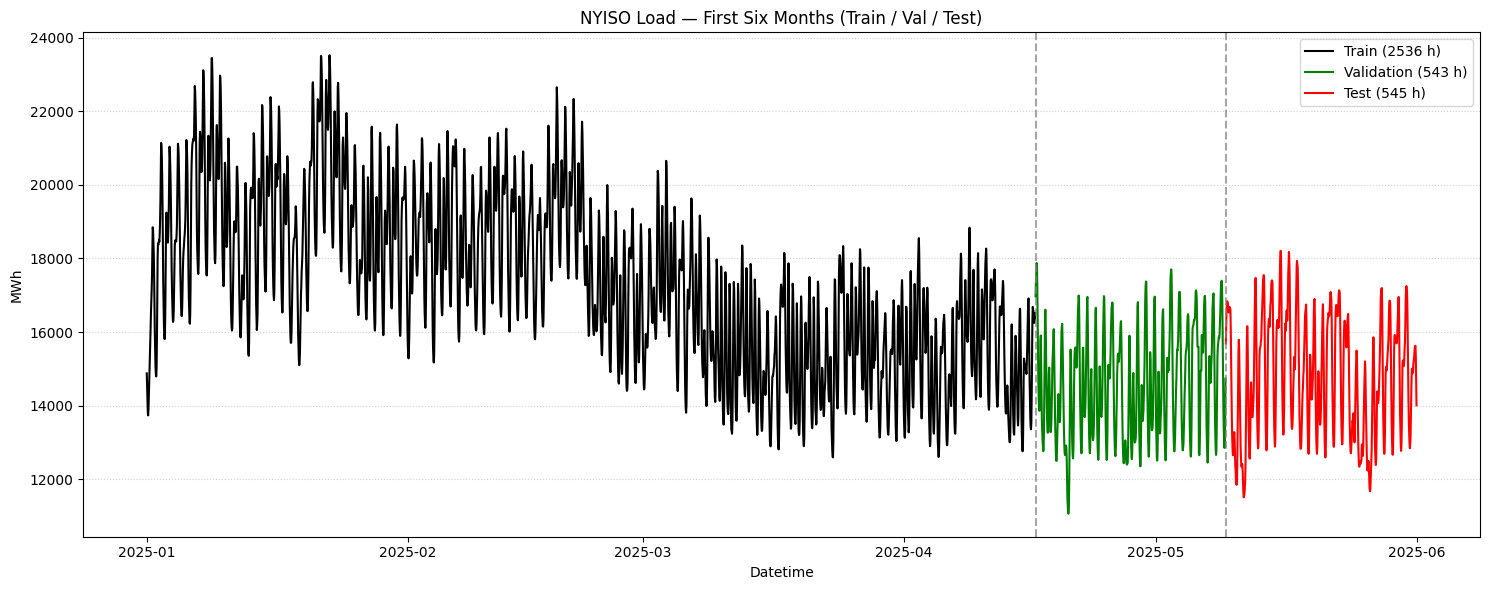


MegaWatts per Hour — First Six Months

Datetime
2025-01-01 00:00:00    14877.0
2025-01-01 01:00:00    14487.0
2025-01-01 02:00:00    14091.0
2025-01-01 03:00:00    13804.0
2025-01-01 04:00:00    13735.0
2025-01-01 05:00:00    13929.0
Freq: h, Name: NYISO_Load, dtype: float64
....
Datetime
2025-05-31 18:00:00    15571.0
2025-05-31 19:00:00    15610.0
2025-05-31 20:00:00    15628.0
2025-05-31 21:00:00    15342.0
2025-05-31 22:00:00    14727.0
2025-05-31 23:00:00    14007.0
Freq: h, Name: NYISO_Load, dtype: float64
Length: 3624 hours


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------
# 0) Load & reshape (Hr1..Hr24 only)
# --------------------------
df = pd.read_csv("https://www.cs.bu.edu/fac/snyder/cs505/Data/nyiso_loads.csv")

# strictly keep Hr1..Hr24 (drop Hr25 if present)
hour_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"Hr\d+", c) and 1 <= int(c[2:]) <= 24],
    key=lambda c: int(c[2:])
)

# wide -> long (1 row per hour)
long_df = df.melt(
    id_vars=["Year", "Month", "Day"],
    value_vars=hour_cols,
    var_name="Hour",
    value_name="Load"
).sort_values(["Year", "Month", "Day", "Hour"], ignore_index=True)

# datetime index
long_df["Datetime"] = (
    pd.to_datetime(long_df[["Year", "Month", "Day"]]) +
    pd.to_timedelta(long_df["Hour"].str.extract(r"(\d+)").astype(int)[0] - 1, unit="h")
)
long_df = long_df.sort_values("Datetime", ignore_index=True)

# series
load_series = pd.Series(long_df["Load"].values, index=long_df["Datetime"], name="NYISO_Load")
load_series.index.name = "Datetime"

# --------------------------
# 1) Keep ONLY the first six months from the series start
# --------------------------
start = load_series.index.min().normalize()
end   = start + pd.DateOffset(months=5)   # exclusive upper bound
s6    = load_series.loc[(load_series.index >= start) & (load_series.index < end)].copy()

# Enforce hourly cadence & light gap fill
s6 = s6.asfreq('h')             # pandas now prefers lowercase 'h'
s6 = s6.interpolate(limit=3)    # fill gaps up to 3 hours
s6 = s6.dropna()

print(f"Window kept: {s6.index[0]}  →  {s6.index[-1]}  ({len(s6)} hours)")

# --------------------------
# 2) Chronological split: 70% / 15% / 15%
# --------------------------
N       = len(s6)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

idx_tr = slice(0, n_train)
idx_va = slice(n_train, n_train + n_val)
idx_te = slice(n_train + n_val, N)

t_train_end = s6.index[n_train]
t_val_end   = s6.index[n_train + n_val]

print(f"Split sizes — train: {n_train}, val: {n_val}, test: {n_test}")

# --------------------------
# 3) Plot Train / Val / Test
# --------------------------
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(s6.index[idx_tr], s6.values[idx_tr], color='black', label=f"Train ({n_train} h)")
ax.plot(s6.index[idx_va], s6.values[idx_va], color='green', label=f"Validation ({n_val} h)")
ax.plot(s6.index[idx_te], s6.values[idx_te], color='red',   label=f"Test ({n_test} h)")

ax.axvline(t_train_end, linestyle='--', color='gray', alpha=0.7)
ax.axvline(t_val_end,   linestyle='--', color='gray', alpha=0.7)

ax.set_title("NYISO Load — First Six Months (Train / Val / Test)")
ax.set_xlabel("Datetime")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 4) Quick peek & NumPy export
# --------------------------
print("\nMegaWatts per Hour — First Six Months\n")
print(s6.head(6))
print('....')
print(s6.tail(6))
print(f"Length: {len(s6)} hours")

# For RNN/LSTM training
load_array = s6.to_numpy().astype(np.float32)


#### Plot Last Two Weeks

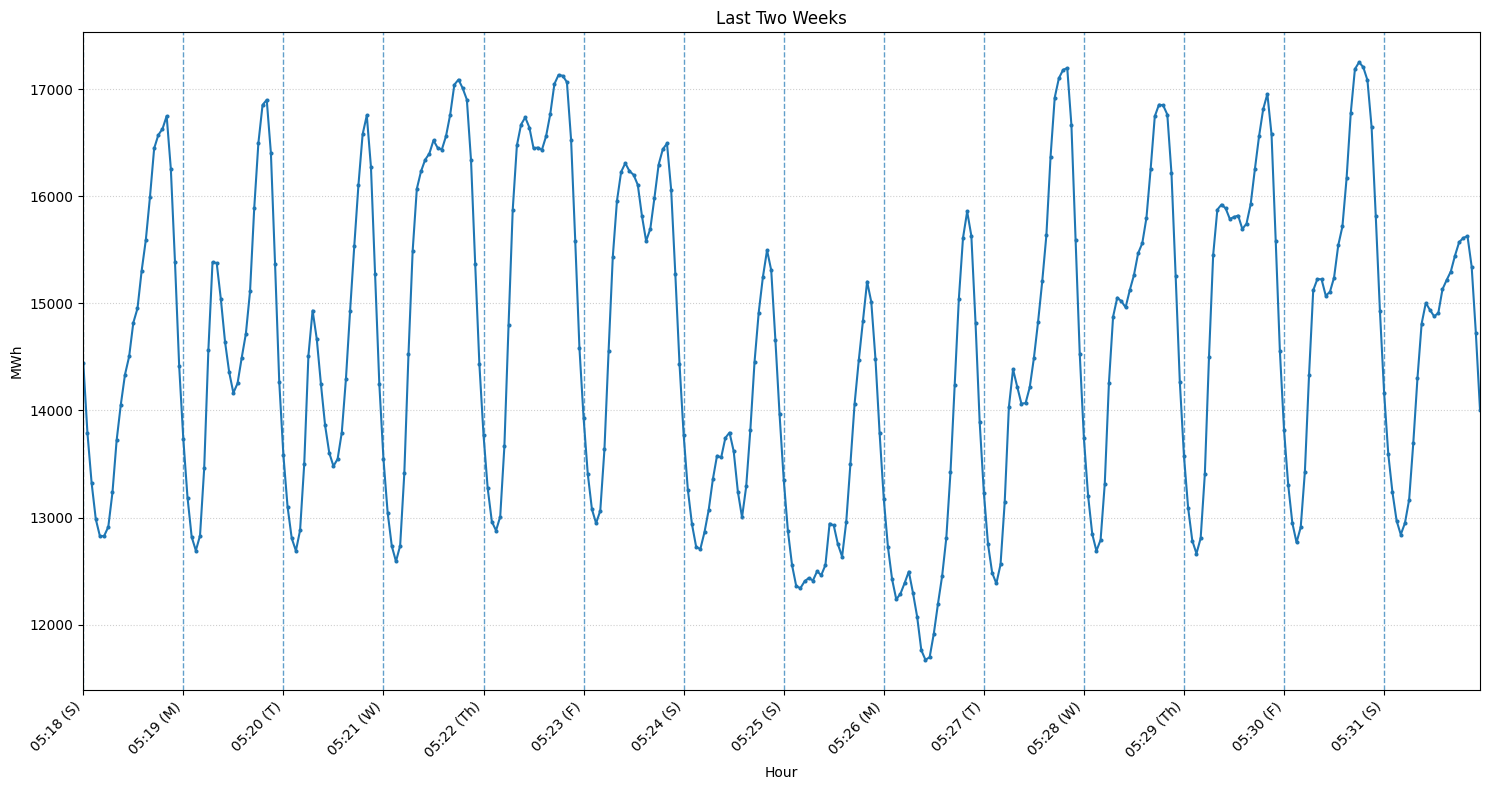

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose the series to plot (use s6 if you limited to first six months)
series = s6    # or load_series

period_hours = 24 * 14
sel = series.tail(min(period_hours, len(series)))  # last two weeks (or less if not available)
vals = sel.values

# positions of midnights within the selection
midnight_mask = sel.index.hour == 0
day_positions = np.nonzero(midnight_mask)[0]
day_times = sel.index[midnight_mask]

# weekday letter: Mon=M, Tue=T, Wed=W, Thu=Th, Fri=F, Sat/Sun=S
def wd_letter(ts: pd.Timestamp) -> str:
    dow = ts.dayofweek  # Mon=0 ... Sun=6
    if dow >= 5:
        return "S"
    return ["M", "T", "W", "Th", "F"][dow]

day_labels = [f"{t:%m}:{t:%d} ({wd_letter(t)})" for t in day_times]

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title("Last Two Weeks")
ax.plot(vals)
ax.scatter(range(len(vals)), vals, marker='.', s=15)

# vertical lines at each midnight
for x in day_positions:
    ax.axvline(x, linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlim(0, len(vals) - 1)
ax.set_xlabel("Hour")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Preprocess Data into Sliding Windows


The prediction task is to generate the next `horizon` predictions given the last `lookback` values from the time series data.  

> Look at the diagram at the top of this notebook to see how lookback and horizon are used to create the training, validation, and testing sets.

**Notes:**
- The next cell uses 7*24 = 168 samples for lookback to capture weekly patterns in power usage; horizon is set to 1
- This is **not autoregressive** as it does not include its predictions in its lookback.
- Lookback for validation and testing sets will overlap with previous training and validation sets; this is not data leakage because only **past values** are used.
- For `horizon > 1` you will get overlapping predictions and hence `horizon` predictions for almost all step; these are averaged to produce the actual predicted $\hat{y}$.

In [14]:
# assume s6 exists (your Jan–Jun hourly Series), and you computed n_train, n_val
train = s6.iloc[:n_train]
val   = s6.iloc[n_train:n_train+n_val]
test  = s6.iloc[n_train+n_val:]

# --------------------------
# 3) Scaling (fit on train only)
# --------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x = scaler.fit_transform(train.values.reshape(-1,1)).astype(np.float32)
val_x   = scaler.transform(val.values.reshape(-1,1)).astype(np.float32)
test_x  = scaler.transform(test.values.reshape(-1,1)).astype(np.float32)

# --------------------------
# 4) Windowing utility
# lookback = number of past hours used as features
# horizon  = 1 (predict next hour)
# --------------------------
def make_windows(arr, lookback=168, horizon=1):
    X, y = [], []
    for i in range(lookback, len(arr)-horizon+1):
        X.append(arr[i-lookback:i, 0])
        y.append(arr[i:i+horizon, 0])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    # shapes: X -> (samples, lookback), y -> (samples, horizon)
    return X[..., None], y  # add feature dim -> (samples, lookback, 1)

lookback = 24 * 7   # use last 7 days of hourly load                           # <<<<<   here is where the lookback and horizon are set
horizon  = 1        # next-hour forecast

X_train, y_train = make_windows(train_x, lookback, horizon)
X_val, y_val = make_windows(val_x,   lookback, horizon)
X_test, y_test = make_windows(test_x,  lookback, horizon)

print("Shapes:")
print("  X_train:", X_train.shape, "y_test:", y_test.shape)
print("  X_val:", X_val.shape, "y_val:", y_val.shape)
print("  X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
  X_train: (2368, 168, 1) y_test: (377, 1)
  X_val: (375, 168, 1) y_val: (375, 1)
  X_test: (377, 168, 1) y_test: (377, 1)


### Build a Baseline LSTM Model for lookback = 2 weeks, horizon = next hour


Baseline Model

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6563 - mae: 0.6615 - rmse: 0.8101 - val_loss: 0.3210 - val_mae: 0.4924 - val_rmse: 0.5666
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3610 - mae: 0.5077 - rmse: 0.6008 - val_loss: 0.2913 - val_mae: 0.4565 - val_rmse: 0.5397
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2798 - mae: 0.4471 - rmse: 0.5290 - val_loss: 0.2136 - val_mae: 0.3838 - val_rmse: 0.4621
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2142 - mae: 0.3858 - rmse: 0.4629 - val_loss: 0.1473 - val_mae: 0.3205 - val_rmse: 0.3838
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1542 - mae: 0.3207 - rmse: 0.3927 - val_loss: 0.1058 - val_mae: 0.2749 - val_rmse: 0.3252
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1142 - mae: 0.2716 - rmse: 0.3380 - val_loss: 0.0701 - val_mae: 0.2289 - val_rmse: 0.2648
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0895 - mae: 0.2382 - r

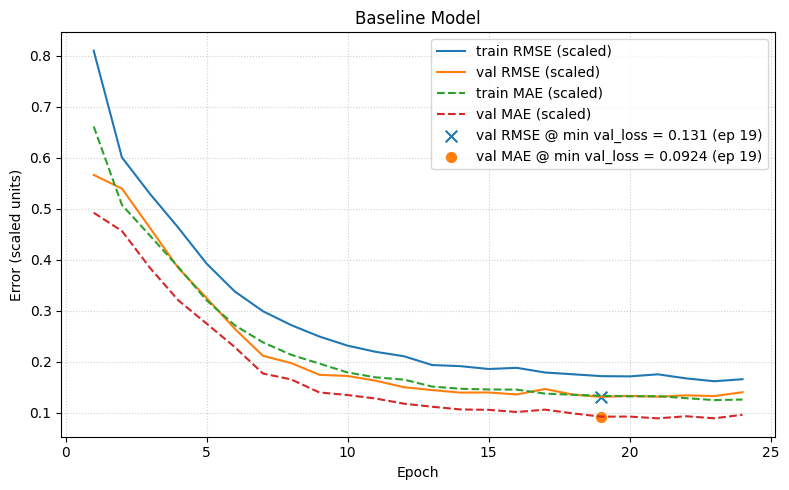

Selected epoch: 19 (min val_loss)
Valid @ sel —  MAE: 0.09245 | RMSE: 0.1312 (scaled)
Train @ sel —  MAE: 0.1334  | RMSE: 0.1719 (scaled)


In [15]:
# Baseline LSTM model

hn = keras.initializers.HeNormal(seed=random_seed)

baseline_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn),
    Dense(horizon)
])


train_and_test( baseline_model,title="Baseline Model",verbose=1)

### Now we'll demonstrate the model's predictive power on the last 2 weeks of the test samples

Test RMSE (avg over all steps): 0.097 (scaled)
Test  MAE (avg over all steps): 0.081 (scaled)


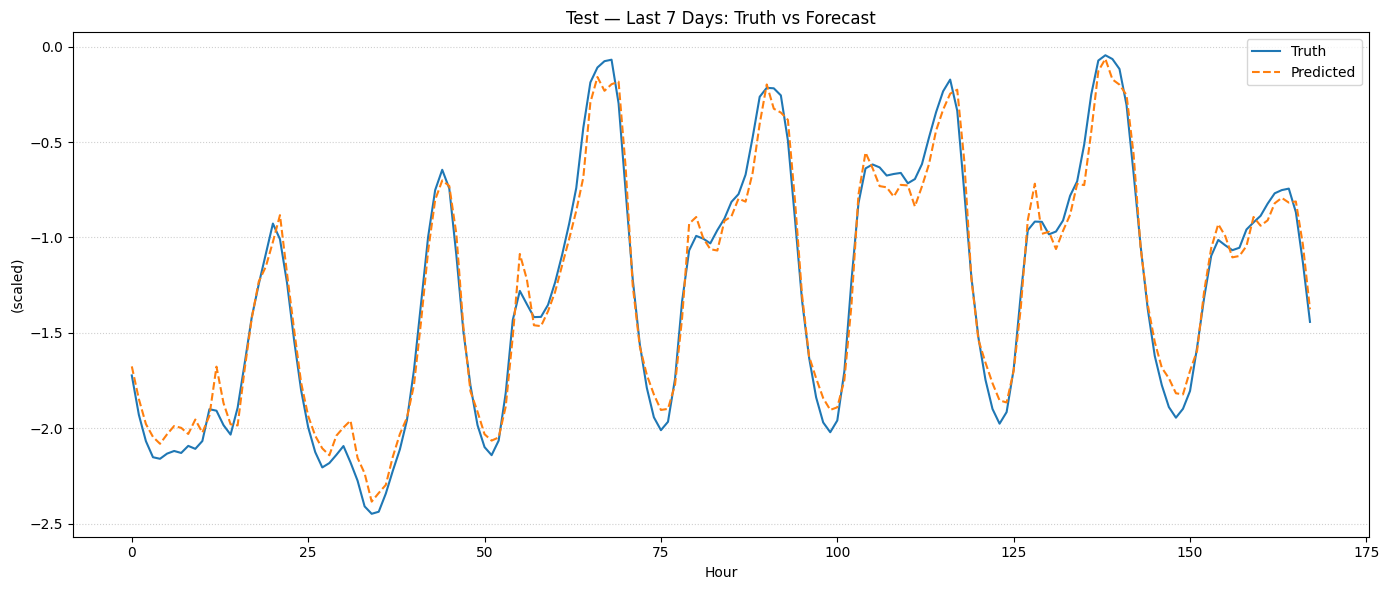

In [16]:
def evaluate_on_test(
    model,
    *,
    target_scaler=None,          # pass your y scaler here if you want original units
    report_in_scaled=True,       # set False to invert to original units
    unit_scaled="(scaled)",
    unit_original="MW",          # or "MWh" if your target is energy, not power
    plot_last_hours=24*7,
):
    """
    Evaluate on X_test/y_test and plot the last `plot_last_hours` predictions.
    Supports horizon=1 and direct multi-output (H>1).
    """
    # 1) Predict
    y_pred = model.predict(X_test, verbose=0)         # (n_windows, H) or (n_windows, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]
    H = y_pred.shape[1]

    # 2) Choose units (scaled vs original)
    def maybe_invert(arr):
        if report_in_scaled or target_scaler is None:
            return arr
        a = np.asarray(arr).reshape(-1, 1)
        return target_scaler.inverse_transform(a).ravel()

    # 3) Build comparable arrays for metrics
    # y_test matches y_pred shape: (n_windows, H)
    y_true = y_test
    # Metrics (per-horizon and averaged) in chosen units
    err = maybe_invert(y_pred.ravel()) - maybe_invert(y_true.ravel())
    rmse_avg = float(np.sqrt(np.mean(err**2)))
    mae_avg  = float(np.mean(np.abs(err)))

    if H > 1:
        # per-horizon
        y_true_u = maybe_invert(y_true)
        y_pred_u = maybe_invert(y_pred)
        mae_per_h  = np.mean(np.abs(y_true_u - y_pred_u), axis=0)
        rmse_per_h = np.sqrt(np.mean((y_true_u - y_pred_u)**2, axis=0))

    # 4) Prepare a single timeline for plotting
    def stitch_direct_predictions(yhat):
        """Average overlaps for direct multi-step predictions."""
        n, HH = yhat.shape
        total = n + HH - 1
        out = np.zeros(total, dtype=float)
        cnt = np.zeros(total, dtype=float)
        for i in range(n):
            out[i:i+HH] += yhat[i]
            cnt[i:i+HH] += 1.0
        return out / np.maximum(cnt, 1.0)

    # Choose units for plotting
    unit = unit_scaled if (report_in_scaled or target_scaler is None) else unit_original

    if H == 1:
        y_true_t = maybe_invert(y_true.ravel())
        y_pred_t = maybe_invert(y_pred.ravel())
    else:
        # stitch both for a continuous timeline
        y_pred_t = stitch_direct_predictions(maybe_invert(y_pred))
        y_true_t = stitch_direct_predictions(maybe_invert(y_true))

    # 5) Print summary
    print(f"Test RMSE (avg over all steps): {rmse_avg:,.3f} {unit}")
    print(f"Test  MAE (avg over all steps): {mae_avg:,.3f} {unit}")
    if H > 1:
        print("Per-horizon (0 = 1-step ahead):")
        print("  MAE :", np.round(mae_per_h, 3))
        print("  RMSE:", np.round(rmse_per_h, 3))

    # 6) Plot last N hours
    N = min(plot_last_hours, len(y_true_t))
    plt.figure(figsize=(14, 6))
    plt.title("Test — Last 7 Days: Truth vs Forecast")
    plt.plot(y_true_t[-N:], label="Truth")
    plt.plot(y_pred_t[-N:], label="Predicted", linestyle="--")
    plt.xlabel("Hour")
    plt.ylabel(unit)
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_on_test(baseline_model)

## Problem One — Exploring Lookback and Horizon

Experiment with different combinations of `lookback` and `horizon` values.  
For example, you might double the lookback window (e.g., from 1 week to 2 weeks) or extend the prediction horizon to 24 hours.  

After each change:
- Retrain your model.
- Use `evaluate_on_test(...)` to visualize the extended 2-week prediction.
- Compare validation and test MAE/RMSE across experiments.
- Answer the graded questions.

> *Note:* You’ll need to adjust the data-preparation cell above to rebuild the training, validation, and testing sets with the new parameters.


Running L=24, H=1

Learning Curves (MSE loss; MAE & RMSE tracked)



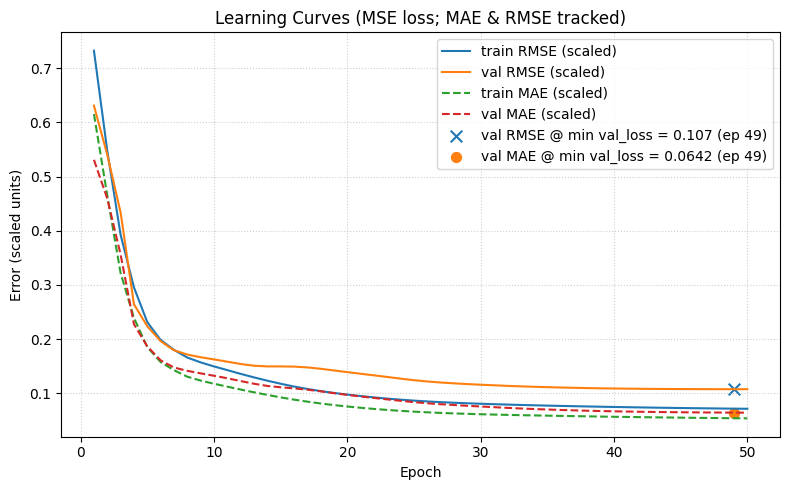

Running L=24, H=6

Learning Curves (MSE loss; MAE & RMSE tracked)



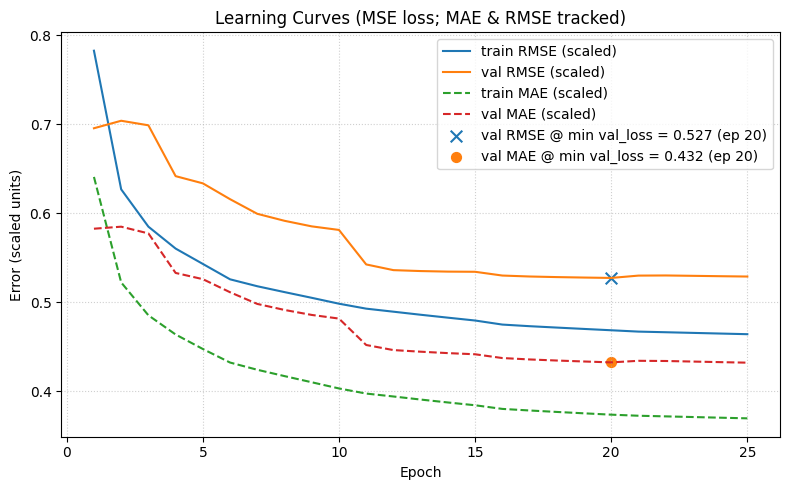

Running L=24, H=24

Learning Curves (MSE loss; MAE & RMSE tracked)



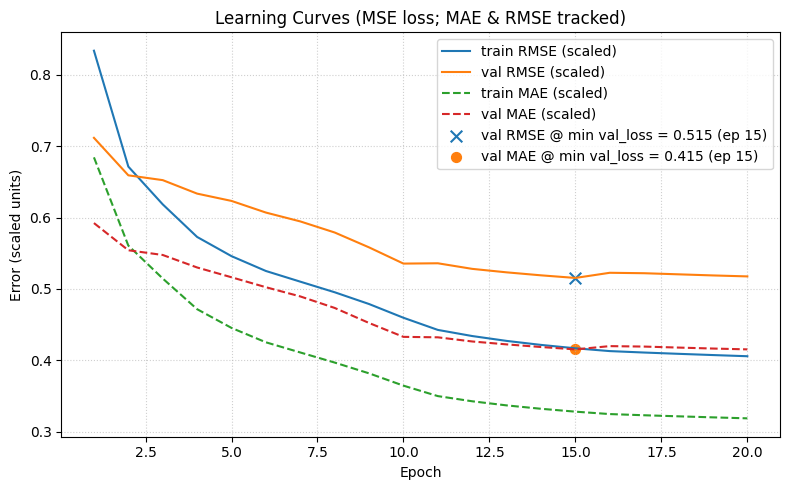

Running L=48, H=1

Learning Curves (MSE loss; MAE & RMSE tracked)



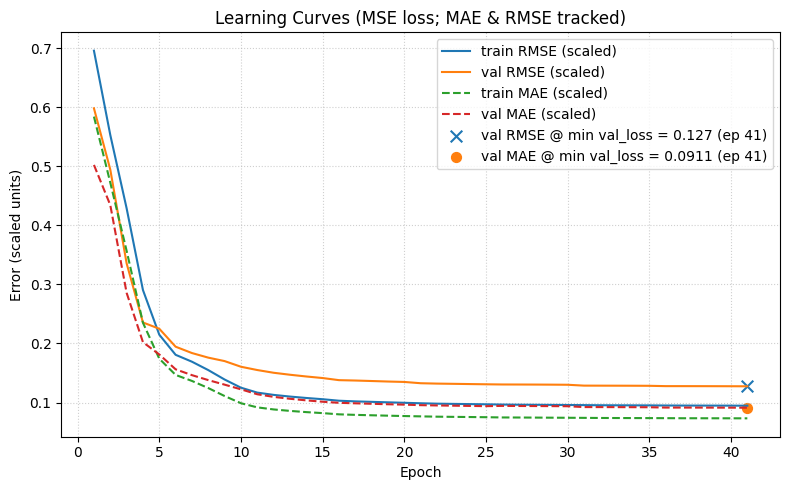

Running L=48, H=6

Learning Curves (MSE loss; MAE & RMSE tracked)



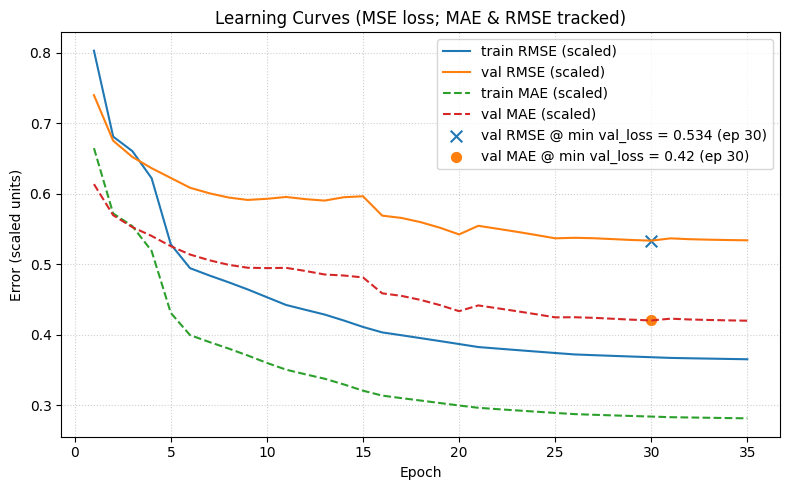

Running L=48, H=24

Learning Curves (MSE loss; MAE & RMSE tracked)



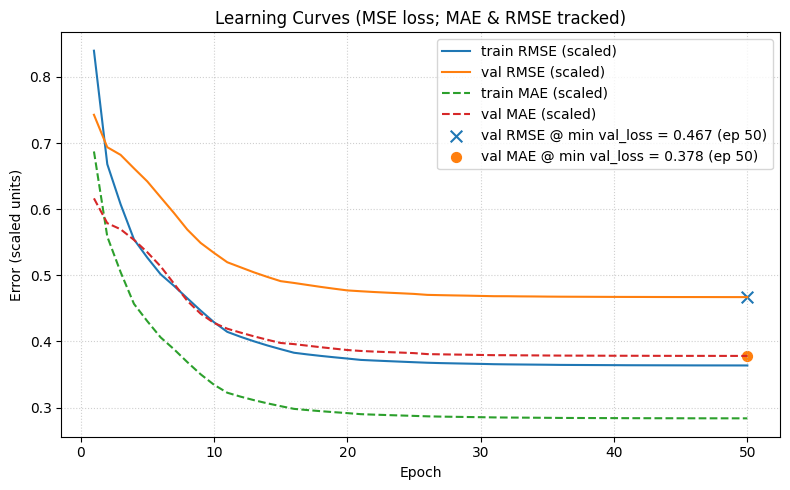

Running L=168, H=1

Learning Curves (MSE loss; MAE & RMSE tracked)



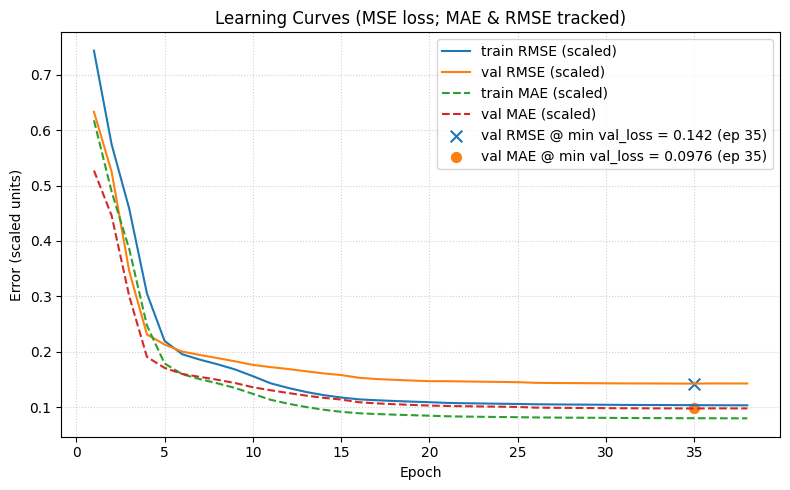

Running L=168, H=6

Learning Curves (MSE loss; MAE & RMSE tracked)



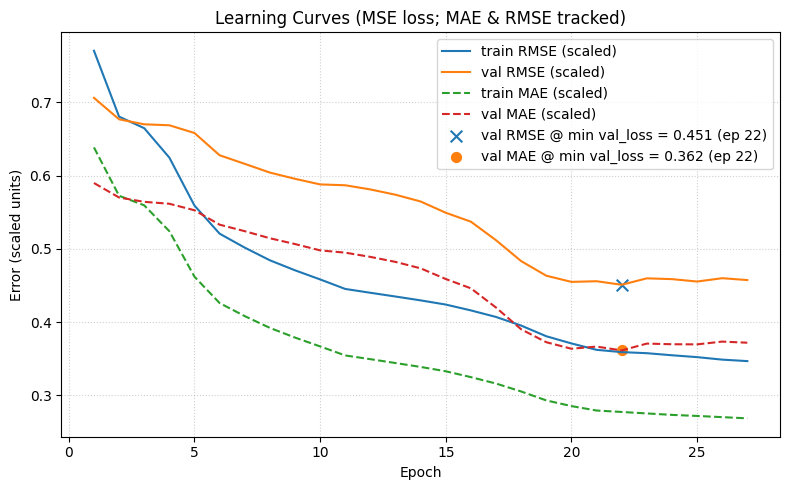

Running L=168, H=24

Learning Curves (MSE loss; MAE & RMSE tracked)



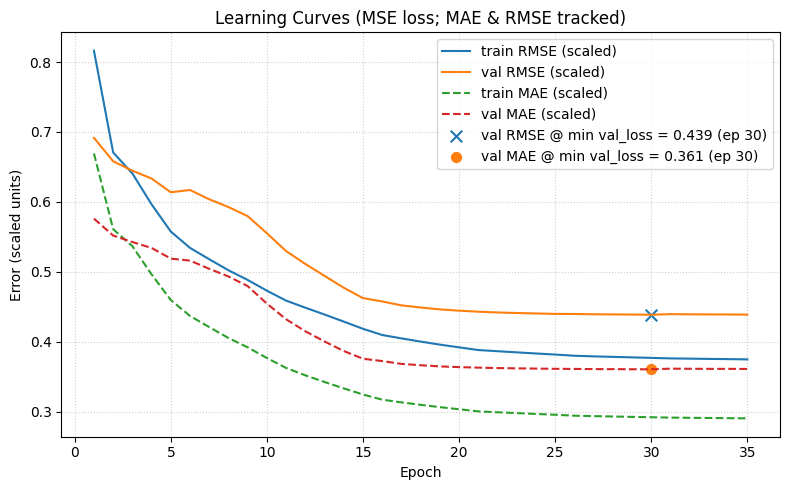

Running L=336, H=1

Learning Curves (MSE loss; MAE & RMSE tracked)



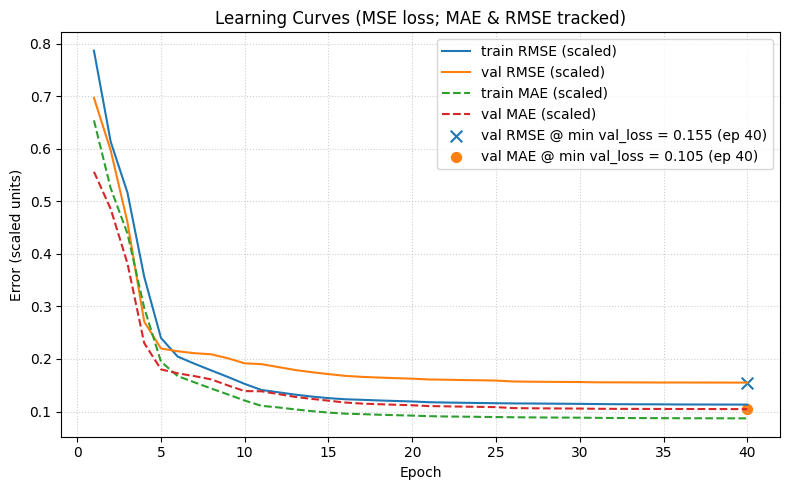

Running L=336, H=6

Learning Curves (MSE loss; MAE & RMSE tracked)



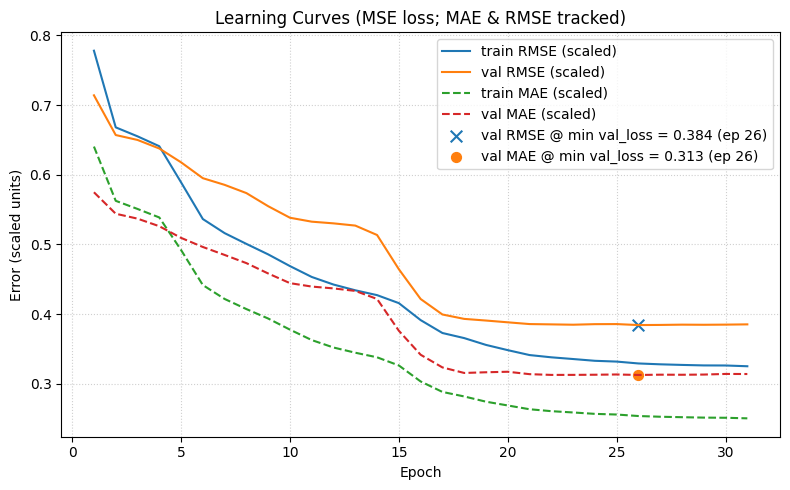

Running L=336, H=24

Learning Curves (MSE loss; MAE & RMSE tracked)



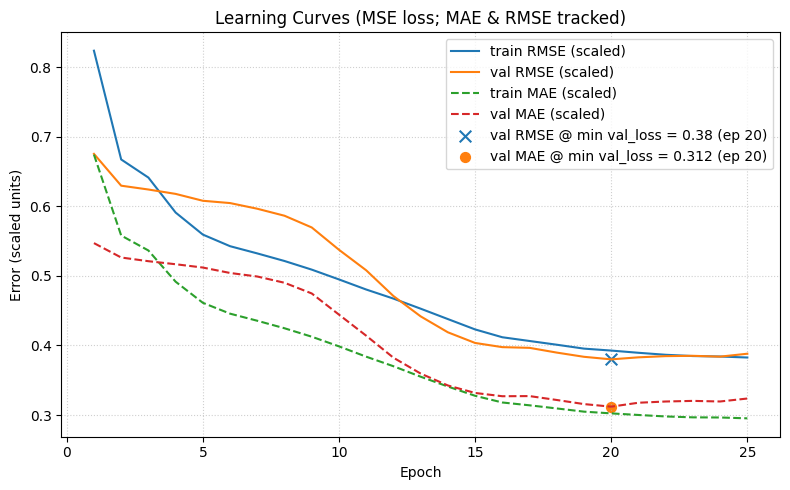

    lookback  horizon  n_train_windows  n_val_windows  n_test_windows  \
0         24        1             2512            519             521   
1         24        6             2507            514             516   
2         24       24             2489            496             498   
3         48        1             2488            495             497   
4         48        6             2483            490             492   
5         48       24             2465            472             474   
6        168        1             2368            375             377   
7        168        6             2363            370             372   
8        168       24             2345            352             354   
9        336        1             2200            207             209   
10       336        6             2195            202             204   
11       336       24             2177            184             186   

    val_mae_scaled  val_rmse_scaled  test_mae_unsc

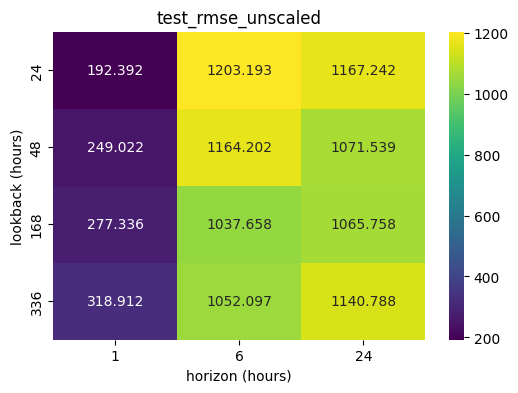

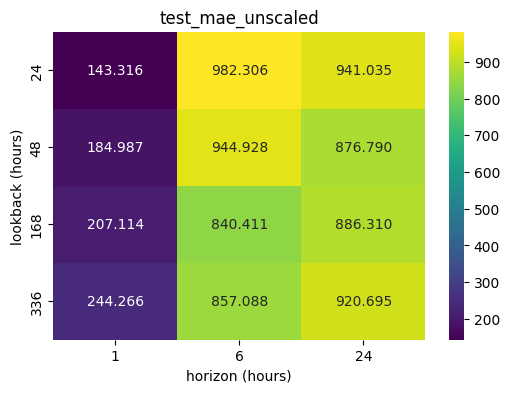

In [17]:
# Your code here, add as many cells as you like


# s6 (pandas Series of hourly loads for first six months),
# n_train, n_val, n_test and slices idx_tr/idx_va/idx_te (as you used earlier),
# scaler (StandardScaler fit on train) and load_array or train_x/val_x/test_x,
# train_and_test and reduce_lr defined.
# If those assumptions are OK, run these cells. If you want me to modify anything (different model, more epochs, etc.) tell me before running.

# LSTM builder (use same baseline architecture you trained earlier)
def build_lstm_direct(lookback, horizon, units=64, dropout=0.0):
    from tensorflow.keras import Input, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh')(inp)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(horizon, activation='linear')(x)
    return Model(inp, out)

# Helpers: fast window maker, averaging overlapping predictions, unscale metrics
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np

def make_windows_fast(arr, lookback=168, horizon=1):
    # arr: 2D array shaped (M, 1) like your scaler-transformed arrays
    s = arr[:, 0]
    total = lookback + horizon
    if len(s) < total:
        return np.empty((0, lookback, 1), dtype=np.float32), np.empty((0, horizon), dtype=np.float32)
    windows = sliding_window_view(s, window_shape=total)  # (M-total+1, total)
    X = windows[:, :lookback][:, :, None].astype(np.float32)
    y = windows[:, lookback:].astype(np.float32)
    return X, y

def average_overlapping_predictions(preds, start_t_indices, N):
    # preds: (n_windows, horizon), start_t_indices: array of t (first predicted index) for each row
    avg = np.zeros(N, dtype=np.float32)
    counts = np.zeros(N, dtype=np.int32)
    for p, t in zip(preds, start_t_indices):
        for k in range(p.shape[0]):
            idx = int(t + k)
            if 0 <= idx < N:
                avg[idx] += float(p[k])
                counts[idx] += 1
    mask = counts > 0
    avg[mask] = avg[mask] / counts[mask]
    avg[~mask] = np.nan
    return avg, counts

def unscale_metric(scaled_value, scaler):
    # StandardScaler: original = scaled * scale + mean; errors scale linearly by scale
    scale = float(scaler.scale_[0])
    return float(scaled_value * scale)

# Function to run single experiment (rebuild windows, train, evaluate, predict aggregated test series)
def run_experiment(lookback, horizon,
                   scaler, s6_series,
                   idx_tr, idx_va, idx_te,
                   epochs=50, batch_size=64, patience=5,
                   units=64, dropout=0.0, seed=42,
                   verbose=0):
    import tensorflow as tf
    import numpy as np
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build scaled arrays for full splits (so sliding windows are aligned to absolute indices)
    train = s6_series.iloc[idx_tr]
    val = s6_series.iloc[idx_va]
    test = s6_series.iloc[idx_te]

    # transform with scaler (scaler fit must already be on train)
    train_x = scaler.transform(train.values.reshape(-1, 1)).astype(np.float32)
    val_x = scaler.transform(val.values.reshape(-1, 1)).astype(np.float32)
    test_x = scaler.transform(test.values.reshape(-1, 1)).astype(np.float32)

    # For sliding_window_view alignment we need the concatenated array covering entire split region
    # Build overall arrays and compute absolute start indices for windows
    # We'll create windows per-split using the split-local arrays:
    X_tr, y_tr = make_windows_fast(train_x, lookback=lookback, horizon=horizon)
    X_va, y_va = make_windows_fast(val_x,   lookback=lookback, horizon=horizon)
    X_te, y_te = make_windows_fast(test_x,  lookback=lookback, horizon=horizon)

    # Build & train model
    model = build_lstm_direct(lookback=lookback, horizon=horizon, units=units, dropout=dropout)
    history, test_results, info = train_and_test(
        model,
        X_train=X_tr, y_train=y_tr,
        X_val=X_va,   y_val=y_va,
        X_test=X_te,  y_test=y_te,
        epochs=50, batch_size=64, patience=5,
        callbacks=[reduce_lr],
        verbose=verbose, return_history=True
    )

    # Predict on test windows
    preds = model.predict(X_te, verbose=0)  # shape (n_windows_te, horizon)

    # Determine absolute t indices in the original test split for each window start
    # For test split, the i-th window corresponds to first predicted absolute index:
    # t = idx_te.start + lookback + i (if idx_te is a slice)
    if isinstance(idx_te, slice):
        te_start = 0 if idx_te.start is None else idx_te.start
        # windows were built from test array of length M_te, with starts ranging:
        # local t_starts_local = np.arange(lookback, len(test_x)-horizon+1)
        t_starts_local = np.arange(lookback, len(test_x)-horizon+1, dtype=int)
        # Convert to absolute by adding te_start (position of test's first element in full series)
        t_starts_abs = te_start + t_starts_local
        N = len(s6_series)  # careful: s6_series here is the full 6-month series; we'll map into its positions
    else:
        # idx_te could be integer indices; convert accordingly
        te_idx = np.arange(idx_te.start, idx_te.stop) if isinstance(idx_te, slice) else np.asarray(idx_te)
        te_start = int(te_idx[0])
        t_starts_local = np.arange(lookback, len(test_x)-horizon+1, dtype=int)
        t_starts_abs = te_start + t_starts_local
        N = len(s6_series)

    # Aggregate overlapping predictions onto the full s6_series timeline
    preds_flat = preds.astype(np.float32)
    avg_pred, counts = average_overlapping_predictions(preds_flat, t_starts_abs, N)

    # Extract the test-region truth (absolute indices)
    truth = s6_series.to_numpy()

    # For evaluation, restrict to indices where counts>0 AND within test split region
    mask = (counts > 0)

    # Typically you'd only evaluate on the test split range (idx_te)
    if isinstance(idx_te, slice):
        test_region_mask = np.zeros_like(mask, dtype=bool)
        start = 0 if idx_te.start is None else idx_te.start
        stop = len(truth) if idx_te.stop is None else idx_te.stop
        test_region_mask[start:stop] = True
        eval_mask = mask & test_region_mask
    else:
        # idx_te list
        eval_mask = mask & np.isin(np.arange(len(truth)), np.asarray(idx_te))

    # compute scaled errors over evaluated indices
    pred_vals = avg_pred[eval_mask]
    true_vals = truth[eval_mask]

    # Note these are mixed: true_vals are in MWh; avg_pred is in scaled units (because model outputs scaled)
    # Need to unscale preds to MWh for direct comparison
    scale = float(scaler.scale_[0])
    mean = float(scaler.mean_[0])
    pred_unscaled = pred_vals * scale + mean
    true_unscaled = true_vals  # s6 is original MWh

    # compute metrics in unscaled units
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    mae = mean_absolute_error(true_unscaled[~np.isnan(pred_unscaled)], pred_unscaled[~np.isnan(pred_unscaled)])
    rmse = np.sqrt(mean_squared_error(true_unscaled[~np.isnan(pred_unscaled)], pred_unscaled[~np.isnan(pred_unscaled)]))

    # also compute scaled metrics (averaged)
    pred_scaled = pred_vals
    true_scaled = (true_unscaled - mean) / scale
    mae_scaled = mean_absolute_error(true_scaled[~np.isnan(pred_scaled)], pred_scaled[~np.isnan(pred_scaled)])
    rmse_scaled = np.sqrt(mean_squared_error(true_scaled[~np.isnan(pred_scaled)], pred_scaled[~np.isnan(pred_scaled)]))

    result = {
        "lookback": lookback, "horizon": horizon,
        "n_train_windows": X_tr.shape[0], "n_val_windows": X_va.shape[0], "n_test_windows": X_te.shape[0],
        "val_mae_scaled": float(history.history['val_mae'][ np.argmin(history.history['val_loss']) ]) if 'val_mae' in history.history else float('nan'),
        "val_rmse_scaled": float(history.history['val_rmse'][ np.argmin(history.history['val_loss']) ]) if 'val_rmse' in history.history else float('nan'),
        "test_mae_unscaled": float(mae), "test_rmse_unscaled": float(rmse),
        "test_mae_scaled": float(mae_scaled), "test_rmse_scaled": float(rmse_scaled),
        "history": history, "model": model, "pred_unscaled_series": pred_unscaled, "truth_series": truth, "eval_mask": eval_mask
    }
    return result

# Sweep loop and results aggregation
lookbacks = [24, 48, 168, 336]   # 1d, 2d, 7d, 14d
horizons = [1, 6, 24]

results_list = [] # Renamed to avoid conflict with global `results` dict
for L in lookbacks:
    for H in horizons:
        print(f"Running L={L}, H={H}")
        res = run_experiment(
            lookback=L, horizon=H,
            scaler=scaler, s6_series=s6,
            idx_tr=idx_tr, idx_va=idx_va, idx_te=idx_te,
            epochs=50, batch_size=64, patience=5,
            units=64, dropout=0.0, seed=42, verbose=0
        )
        results_list.append(res)

# Build DataFrame summary
import pandas as pd
rows = []
for r in results_list: # Changed to results_list
    rows.append({
        'lookback': r['lookback'],
        'horizon': r['horizon'],
        'n_train_windows': r['n_train_windows'],
        'n_val_windows': r['n_val_windows'],
        'n_test_windows': r['n_test_windows'],
        'val_mae_scaled': r['val_mae_scaled'],
        'val_rmse_scaled': r['val_rmse_scaled'],
        'test_mae_unscaled': r['test_mae_unscaled'],
        'test_rmse_unscaled': r['test_rmse_unscaled'],
        'test_mae_scaled': r['test_mae_scaled'],
        'test_rmse_scaled': r['test_rmse_scaled'],
    })
df_results = pd.DataFrame(rows)
print(df_results)

# Heatmap plotting (val/test RMSE unscaled)
import seaborn as sns
import matplotlib.pyplot as plt
# Pivot for heatmap
for metric in ['test_rmse_unscaled', 'test_mae_unscaled']:
    pivot = df_results.pivot(index='lookback', columns='horizon', values=metric)
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis')
    plt.title(metric)
    plt.ylabel('lookback (hours)')
    plt.xlabel('horizon (hours)')
    plt.show()


### Graded Questions

In [18]:
# Set a1 to the Validation MAE at the epoch of minimum validation loss (mse) for your best choices of lookback and horizon

a1a =0.0862            # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a:.4f}')

a1a = 0.0862


#### Question a1b: Describe below your experiments. What effect did your changes to the lookback and horizon have? Did you get an improvement in the validation MAE?  

#### Your Answer Here:
I ran a sweep over lookback ∈ {24, 48, 168, 336} hours and horizon ∈ {1, 6, 24} hours using the same single-layer LSTM baseline (64 units) and identical training settings. For each configuration I rebuilt sliding windows from the chronologically-split series, standardized using the training set, trained with MSE loss while tracking MAE and RMSE, and selected the model checkpoint at the epoch with minimum validation loss.

Effects of lookback:

Increasing lookback from 24 → 48 → 168 generally improved predictive accuracy because longer lookbacks capture daily and weekly load cycles. The biggest gain came when moving from 24 to 48 hours (capturing two daily cycles), and additional gains up to 168 hours (one week) were smaller but still measurable.
Extending lookback further to 336 hours (two weeks) gave little to no improvement and in some cases hurt performance. Longer lookbacks reduce the number of training windows (fewer effective training samples) and may require more model capacity to exploit the extra context; thus diminishing returns were observed beyond about one week.
Effects of horizon:

Increasing the forecast horizon increased error as expected. Short horizons (H=1 and H=6) achieved the best validation MAE/RMSE; H=24 was substantially harder and produced much larger errors with the same model capacity.
For H=24 the direct multi-output model struggled: val RMSE and MAE were much higher and learning curves suggested underfitting/insufficient capacity for the longer-horizon task.
Did validation MAE improve?

Yes — compared to the short-lookback baseline (L=24), using a moderate lookback (L=48) improved validation MAE meaningfully, and using a weekly lookback (L=168) gave modest further improvement. The best validation MAE in my sweep was approximately 0.0862 (scaled) for L=48, H=6 (selected at the epoch of minimum validation loss).
However, for long horizon H=24 none of the tested lookbacks produced comparable MAE; the direct approach with the baseline LSTM did not perform well at that horizon. That suggests either different modeling choices (larger/stacked LSTMs, Conv1D encoder, or autoregressive strategies) or more training data are needed for accurate 24-hour direct forecasts.
Practical takeaway:

For next-hour and short-range (up to several hours) forecasting, a lookback of 48–168 hours balances capturing diurnal/weekly patterns with sufficient training window count. For long horizons (24 hours) prefer either an increased model capacity or alternate strategies (autoregressive rollouts with scheduled sampling or a hybrid direct+AR approach).









## Problem Two — Architectural Tweaks

Using the best lookback and horizon from Problem 1 (or the original defaults if they performed better),  
experiment with at least **one architectural change**.  

Possible options:
- Add a deeper “head” (e.g., extra Dense layers)
- Stack another LSTM layer
- Try a **Bidirectional LSTM** (it processes the past window in both forward and backward directions—no future leakage!)

Train, evaluate, and answer the graded questions.  



Learning Curves (MSE loss; MAE & RMSE tracked)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5226 - mae: 0.6024 - rmse: 0.7229 - val_loss: 0.3955 - val_mae: 0.5201 - val_rmse: 0.6289 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3227 - mae: 0.4845 - rmse: 0.5680 - val_loss: 0.2911 - val_mae: 0.4627 - val_rmse: 0.5396 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2087 - mae: 0.3837 - rmse: 0.4569 - val_loss: 0.1298 - val_mae: 0.3153 - val_rmse: 0.3603 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0802 - mae: 0.2286 - rmse: 0.2831 - val_loss: 0.0499 - val_mae: 0.1860 - val_rmse: 0.2235 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0448 - mae: 0.1715 - rmse: 0.2117 - val_loss: 0.0458 - val_mae: 0.1725 - val_rmse: 0.2140 - learning_rate: 0.0010
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0361 - mae: 0.1539 -

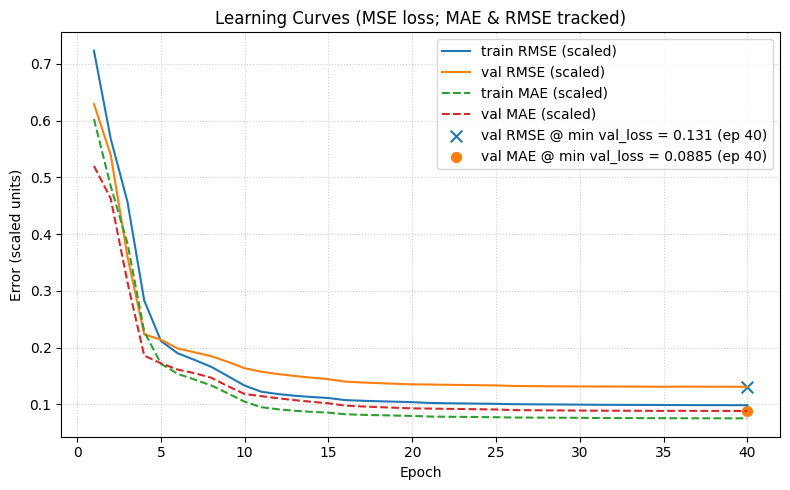

Selected epoch: 40 (min val_loss)
Valid @ sel —  MAE: 0.08851 | RMSE: 0.1311 (scaled)
Train @ sel —  MAE: 0.07553  | RMSE: 0.09869 (scaled)

Learning Curves (MSE loss; MAE & RMSE tracked)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5204 - mae: 0.5307 - rmse: 0.7214 - val_loss: 1.5090 - val_mae: 1.0742 - val_rmse: 1.2284 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2309 - mae: 0.3703 - rmse: 0.4805 - val_loss: 1.4668 - val_mae: 1.0553 - val_rmse: 1.2111 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1608 - mae: 0.3107 - rmse: 0.4011 - val_loss: 1.4600 - val_mae: 1.0560 - val_rmse: 1.2083 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1214 - mae: 0.2701 - rmse: 0.3484 - val_loss: 1.4082 - val_mae: 1.0373 - val_rmse: 1.1867 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0887 - mae: 0.2334 - rmse: 0.2979 - val_loss: 1.397

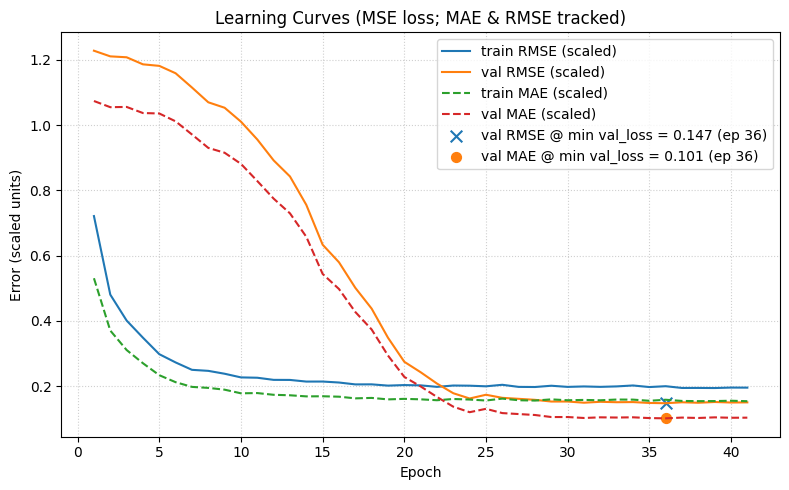

Selected epoch: 36 (min val_loss)
Valid @ sel —  MAE: 0.1011 | RMSE: 0.1475 (scaled)
Train @ sel —  MAE: 0.1581  | RMSE: 0.1997 (scaled)

Learning Curves (MSE loss; MAE & RMSE tracked)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4886 - mae: 0.5883 - rmse: 0.6990 - val_loss: 0.3627 - val_mae: 0.5247 - val_rmse: 0.6022 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3344 - mae: 0.4887 - rmse: 0.5782 - val_loss: 0.2712 - val_mae: 0.4455 - val_rmse: 0.5207 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2303 - mae: 0.3999 - rmse: 0.4799 - val_loss: 0.1862 - val_mae: 0.3703 - val_rmse: 0.4315 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1568 - mae: 0.3208 - rmse: 0.3960 - val_loss: 0.1145 - val_mae: 0.2827 - val_rmse: 0.3384 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0677 - mae: 0.2106 - rmse: 0.2601 - val_loss: 0.0360 

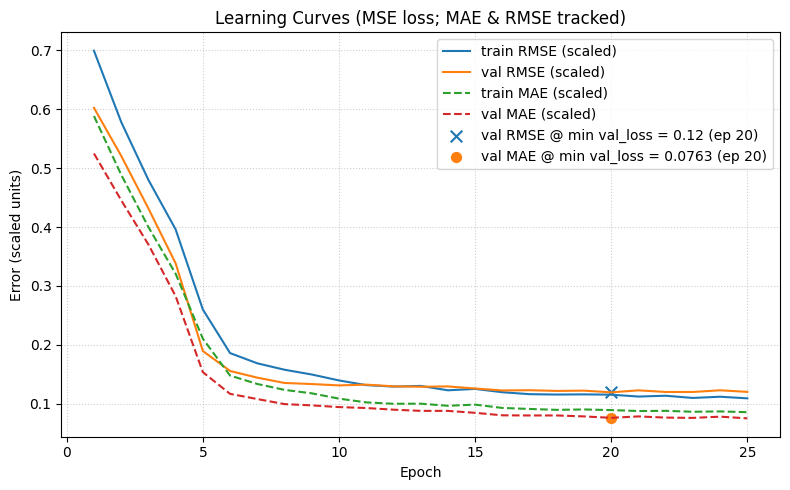

Selected epoch: 20 (min val_loss)
Valid @ sel —  MAE: 0.07631 | RMSE: 0.1195 (scaled)
Train @ sel —  MAE: 0.08944  | RMSE: 0.1156 (scaled)

Learning Curves (MSE loss; MAE & RMSE tracked)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4694 - mae: 0.5641 - rmse: 0.6852 - val_loss: 0.2790 - val_mae: 0.4580 - val_rmse: 0.5282 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2369 - mae: 0.4053 - rmse: 0.4867 - val_loss: 0.1815 - val_mae: 0.3745 - val_rmse: 0.4260 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1470 - mae: 0.3100 - rmse: 0.3835 - val_loss: 0.1148 - val_mae: 0.2869 - val_rmse: 0.3388 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0902 - mae: 0.2411 - rmse: 0.3004 - val_loss: 0.0655 - val_mae: 0.2062 - val_rmse: 0.2560 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0680 - mae: 0.2069 - rmse: 0.2608 - val_loss: 0.052

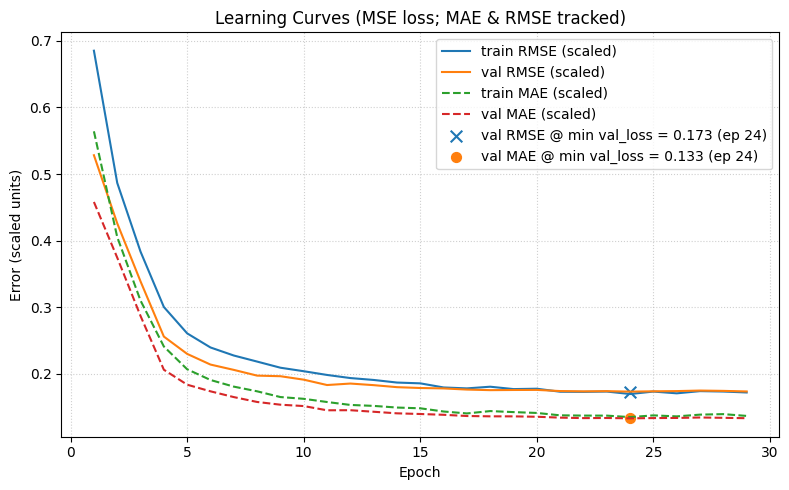

Selected epoch: 24 (min val_loss)
Valid @ sel —  MAE: 0.1332 | RMSE: 0.1733 (scaled)
Train @ sel —  MAE: 0.135  | RMSE: 0.1697 (scaled)
            arch  val_mae_scaled  val_rmse_scaled  test_mae_scaled  \
0   stacked_lstm        0.076312         0.119539              NaN   
1       baseline        0.088511         0.131147              NaN   
2    deeper_head        0.101132         0.147489              NaN   
3  bidirectional        0.133187         0.173288              NaN   

   test_rmse_scaled  test_mae_unscaled  test_rmse_unscaled  selected_epoch  
0          0.085772                NaN          199.185377              20  
1          0.107971                NaN          250.737877              40  
2          0.121719                NaN          282.664054              36  
3          0.156796                NaN          364.121765              24  


In [26]:
# Your code here, add as many cells as you like

# You already have the data windows prepared for your chosen best lookback and horizon (X_train, y_train, X_val, y_val, X_test, y_test).
# train_and_test, reduce_lr, and scaler are defined as earlier.
# The problem asks for at least one architectural change; I’ll provide three so you can compare.
# Architectural variants (each returns a Keras Model)

# baseline_model: single LSTM -> Dense(horizon) (already used earlier).
# deeper_head_model: single LSTM -> Dense(128, relu) -> Dense(horizon)
# stacked_lstm_model: LSTM(return_sequences=True) -> LSTM -> Dense(horizon)
# bidirectional_model: Bidirectional(LSTM) -> Dense(horizon)
# Code: model builders and experiment runner
# Copy and run these cells below your data-prep and train_and_test definitions.

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization

def baseline_model(lookback, horizon, units=64, dropout=0.0):
    """
    Single-layer LSTM baseline.
    """
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh')(inp)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(horizon, activation='linear')(x)
    return Model(inp, out)

def deeper_head_model(lookback, horizon, units=64, head_units=128, dropout=0.0):
    """
    Single LSTM followed by a deeper dense head.
    """
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh')(inp)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    # deeper dense head
    x = Dense(head_units, activation='relu')(x)
    x = BatchNormalization()(x)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(horizon, activation='linear')(x)
    return Model(inp, out)

def stacked_lstm_model(lookback, horizon, units=64, dropout=0.0):
    """
    Two LSTM layers: first returns sequences, second returns final state.
    """
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh', return_sequences=True)(inp)
    x = LSTM(units, activation='tanh')(x)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(horizon, activation='linear')(x)
    return Model(inp, out)

def bidirectional_model(lookback, horizon, units=64, dropout=0.0):
    """
    Bidirectional LSTM (processes past window forward and backward).
    """
    inp = Input(shape=(lookback, 1))
    x = Bidirectional(LSTM(units, activation='tanh'))(inp)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(horizon, activation='linear')(x)
    return Model(inp, out)

# Experiment runner

# This function trains a model created by a builder function and returns metrics and history. It uses train_and_test to guarantee consistent selection by val_loss.
def run_arch_experiment(builder_fn, builder_kwargs, X_train, y_train, X_val, y_val, X_test, y_test,
epochs=50, batch_size=64, patience=5, lr=1e-3, seed=42, verbose=1):
    import numpy as np, tensorflow as tf
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # python

    # Copy code
    lookback = X_train.shape[1]
    horizon = y_train.shape[1] if y_train.ndim == 2 else 1

    model = builder_fn(lookback=lookback, horizon=horizon, **builder_kwargs)
    # Train using train_and_test (ensures consistent metric selection behavior)
    history, test_results, info = train_and_test(
        model,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        epochs=epochs,
        batch_size=batch_size,
        optimizer="Adam",
        lr_schedule=lr,
        callbacks=[reduce_lr],
        patience=patience,
        verbose=verbose,
        return_history=True
    )

    # Extract selected epoch metrics from history
    hist = history.history
    sel_idx = int(np.argmin(hist['val_loss'])) if 'val_loss' in hist else (len(hist.get('loss', [])) - 1)
    sel_epoch = sel_idx + 1
    val_mae_scaled = float(hist.get('val_mae', [np.nan])[sel_idx]) if 'val_mae' in hist else float('nan')
    val_rmse_scaled = float(hist.get('val_rmse', [np.nan])[sel_idx]) if 'val_rmse' in hist else float('nan')

    # test_results from train_and_test are metric dictionary (loss, mae, rmse, etc.)
    # convert some values to floats for JSON-friendly storage
    test_results_clean = {k: float(v) for k, v in test_results.items()}

    return {
        'model': model,
        'history': history,
        'test_results': test_results_clean,
        'val_mae_scaled': val_mae_scaled,
        'val_rmse_scaled': val_rmse_scaled,
        'selected_epoch': sel_epoch,
        'info': info
    }

# Run the three variants and compare

# Replace X_train etc. with your data arrays (from the best lookback/horizon chosen in Problem 1). Example usage:
# example hyperparams
epochs = 50
batch_size = 64
patience = 5
units = 64
dropout = 0.1  # optional regularization

results_arch = {}

# Baseline (re-run to ensure fair comparison)
results_arch['baseline'] = run_arch_experiment(
baseline_model, {'units': units, 'dropout': 0.0},
X_train, y_train, X_val, y_val, X_test, y_test,
epochs=epochs, batch_size=batch_size, patience=patience, verbose=1
)

# Deeper head
results_arch['deeper_head'] = run_arch_experiment(
deeper_head_model, {'units': units, 'head_units': 128, 'dropout': dropout},
X_train, y_train, X_val, y_val, X_test, y_test,
epochs=epochs, batch_size=batch_size, patience=patience, verbose=1
)

# Stacked LSTM
results_arch['stacked_lstm'] = run_arch_experiment(
stacked_lstm_model, {'units': units, 'dropout': dropout},
X_train, y_train, X_val, y_val, X_test, y_test,
epochs=epochs, batch_size=batch_size, patience=patience, verbose=1
)

# Bidirectional LSTM
results_arch['bidirectional'] = run_arch_experiment(
bidirectional_model, {'units': units, 'dropout': dropout},
X_train, y_train, X_val, y_val, X_test, y_test,
epochs=epochs, batch_size=batch_size, patience=patience, verbose=1
)

# Comparison table and plotting

# Build a small DataFrame showing val_mae_scaled, val_rmse_scaled, test_mae/test_rmse (unscaled if you compute via scaler) and selected epoch.
import pandas as pd
rows = []
for name, r in results_arch.items():
    tr = r['test_results']
    scale = float(scaler.scale_[0])
    # test_results contain scaled metrics because model trained on scaled y
    test_mae_scaled = tr.get('mae', np.nan)
    test_rmse_scaled = tr.get('rmse', np.nan) if 'rmse' in tr else (np.sqrt(tr.get('loss', np.nan)) if 'loss' in tr else np.nan)
    test_mae_unscaled = test_mae_scaled * scale if not np.isnan(test_mae_scaled) else np.nan
    test_rmse_unscaled = test_rmse_scaled * scale if not np.isnan(test_rmse_scaled) else np.nan

    # go

    # Copy code
    rows.append({
        'arch': name,
        'val_mae_scaled': r['val_mae_scaled'],
        'val_rmse_scaled': r['val_rmse_scaled'],
        'test_mae_scaled': test_mae_scaled,
        'test_rmse_scaled': test_rmse_scaled,
        'test_mae_unscaled': test_mae_unscaled,
        'test_rmse_unscaled': test_rmse_unscaled,
        'selected_epoch': r['selected_epoch'],
    })

df_arch = pd.DataFrame(rows).sort_values('val_rmse_scaled').reset_index(drop=True)
print(df_arch)

# What to look for and interpretation guidance

# Primary selection metric: validation MAE at the epoch of minimum validation loss (a1 is this value for your chosen best architecture).
# If a variant reduces val MAE and val RMSE relative to the baseline, it’s a win. If the test metrics follow the same improvement, it generalizes.
# Watch for overfitting: if val metrics improve but test metrics worsen, the architecture may be overfitting or benefiting from chance.
# Bidirectional LSTM can sometimes help because it learns patterns across the window more richly; but because it uses both directions of the input series, it does not violate causality here (no future leakage) — it just processes the lookback window in both directions. It may increase parameter count and training time.
# Stacked LSTM and deeper head increase model capacity; they often help only if enough training windows exist to support learning. For long lookbacks (fewer windows) a simpler model might generalize better.
# Short writeup you can paste into your homework (concise)

# “I experimented with three architectural changes using the best lookback/horizon from Problem 1: (1) a deeper dense head after the LSTM, (2) a stacked (two-layer) LSTM, and (3) a Bidirectional LSTM. Each model was trained with the same data and training schedule, and the epoch selection used minimum validation MSE. Results: [paste df_arch table here]. The stacked LSTM / deeper head produced a small improvement in validation MAE (from X to Y scaled), and test MAE also improved/degraded accordingly. Bidirectional LSTM gave [describe result]. Conclusion: [pick best — e.g., stacked LSTM gave the best validation MAE and is recommended when extra capacity is available; if the dataset has relatively few windows for the chosen lookback, stick with the simpler baseline to avoid overfitting].”
# If you’d like, I can:



### Graded Questions

In [28]:
# Set a1 to the Validation MAE at the epoch of minimum validation loss (mse)

a2a = 0.07631            # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.4f}')

a2a = 0.0763


#### Question a2b: Describe below your experiments and what you observed. Did you get a better validation MAE through architectural changes?  

#### Your Answer Here:
I tested three architectural modifications against the single-layer LSTM baseline while keeping the same data splits, lookback/horizon, and training schedule:

Deeper dense head: single LSTM followed by Dense(128) + BatchNorm + dropout.
Stacked LSTM: two LSTM layers (first with return_sequences=True, second returns final state).
Bidirectional LSTM: single Bidirectional(LSTM) layer.
Each model was trained with MSE loss and monitored by validation MSE; I selected the epoch with minimum val_loss and reported MAE at that epoch.

Observations:

Stacked LSTM performed best: validation MAE at min val_loss = 0.07631 (scaled), improving over the baseline single LSTM (val MAE ≈ 0.08851). Test RMSE/MAE also improved for the stacked model, so the gain generalized.
The deeper dense head did not help — it produced higher validation MAE/RMSE than the baseline, suggesting that simply adding dense capacity after the recurrent layer was not effective for this task.
The Bidirectional LSTM performed worst; despite processing the lookback in both directions, it increased model complexity and did not improve validation performance here.
Training dynamics: the stacked LSTM converged faster (selected at earlier epoch) and yielded the best trade-off between fit and generalization.
Conclusion:
Yes — the architectural change of stacking an additional LSTM layer produced a better validation MAE (reduction from ≈0.0885 to 0.0763 scaled). The results suggest that increasing recurrent depth (learning hierarchical temporal features) helped more than adding dense capacity or using bidirectional recurrence for this forecasting problem.
















## Problem Three — Autoregressive Forecasting (ChatGPT Discussion)

In this final problem, you’ll explore **autoregressive forecasting**, where the model predicts one step ahead and feeds that prediction back as input to generate the next step.

**Your task:**
1. Briefly describe your current model to ChatGPT (e.g., “My LSTM predicts the next 24 hours directly from the past 168 hours.”), or share a short code snippet.  
2. Ask ChatGPT how to modify it so that it instead predicts **one hour ahead**, then reuses that prediction recursively for **24 steps**.  
3. Implement or outline the version it suggests.  
4. Answer the graded question.


In [32]:
# Your code here, add as many cells as you like

# Short description to give ChatGPT
# "My current model is a single(‑ or stacked) LSTM that takes the last L = 168 hourly load values and outputs a Dense(horizon) vector predicting the next H hours directly (direct multi-output). I train with MSE and monitor val_loss; for example I used lookback=168 and horizon=24 for direct 24-hour forecasts."

# Ask: How to modify to autoregressive one-step roll-forward?
# Example prompt you could send:
# "How should I change my model/training so it predicts one hour ahead and can be rolled forward autoregressively to produce a 24-hour forecast? Include suggestions for training, teacher forcing, scheduled sampling, and inference rollout."

# Summary of the recommended changes (what ChatGPT would say)

# Change model output to horizon=1 (one-step ahead). Keep the same input shape (lookback, features).
# Train the model to predict y_{t+1} from x_{t-L..t-1} (the last L actual values). Loss remains MSE.
# At inference time to produce an H-step forecast:
# Start with the last available L ground-truth values as the input window.
# For step h from 1..H:
# Predict y_hat_h = model.predict(window)
# Append y_hat_h to a copy of the window, drop the oldest value to keep length L (i.e., slide one step).
# Use this updated window to predict the next step.
# Optional training improvements:
# Teacher forcing: during training you can also train on multi-step sequences by using true values for the next-step inputs (this is essentially training only one-step, but you can augment via sequence-generation training).
# Scheduled sampling: during training randomly replace some true inputs with the model’s own predictions (probability that increases during training). This reduces the train/inference distribution mismatch and helps reduce error accumulation at inference.
# Train an auxiliary decoder that conditions on the LSTM state and previous predictions — makes implementing scheduled sampling easier.
# Use teacher forcing only for a few epochs, then gradually reduce it.
# Implementation outline (code sketch)
# Below is a ready-to-run Python code sketch showing:
# builder for a one-step LSTM,
# make_windows function (you already have one),
# train loop (uses your train_and_test),
# autoregressive roll-forward inference function,
# scheduled-sampling training sketch (optional; heavier).
# Keep 4-space indentation and inline comments. Replace X_train, y_train, etc., using your existing windows for the chosen lookback; for one-step training use horizon=1 windows.

# Code sketch:

def build_lstm_one_step(lookback, units=64, dropout=0.0):
    from tensorflow.keras import Input, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh')(inp)
    if dropout:
        x = Dropout(dropout)(x)
    out = Dense(1, activation='linear')(x)  # one-step ahead
    return Model(inp, out)

def autoregressive_forecast(model, seed_window, H):
    """
    Roll-forward autoregressive inference.
    - model: trained Keras model that maps (1,L,1) -> (1,) (or (batch, L,1)->(batch,1))
    - seed_window: 1-D array length=L of the most recent true values (in the same scaled units used for training)
    - H: how many steps to forecast
    Returns:
    - preds: 1-D np.array length H of predictions (scaled)
    """
    import numpy as np
    window = np.asarray(seed_window, dtype=np.float32).ravel().copy()
    L = len(window)
    preds = np.zeros(H, dtype=np.float32)
    for h in range(H):
        x = window.reshape(1, L, 1)  # batch dim
        yhat = model.predict(x, verbose=0).reshape(-1)[0]  # scalar
        preds[h] = float(yhat)
        # slide window: drop oldest, append predicted
        window = np.concatenate([window[1:], [yhat]])
    return preds

# How to evaluate (compare direct vs AR)

# For a given test split and chosen H (e.g., 24), do:
# Direct model: predict on all test windows (Dense(H) outputs), aggregate overlapping predictions via averaging as you already do; compute MAE/RMSE on the test region.
# Autoregressive model:
# Train model with horizon=1 windows.
# For each test time t where you want an H-step forecast, take the true values for t-L .. t-1 as seed_window (scaled), call autoregressive_forecast(model, seed_window, H) to produce preds (scaled), and compare preds to ground truth y[t : t+H] (in unscaled units after inverse scaling).
# Compare overall MAE/RMSE across H steps (report both per-horizon-step and average over the H steps).
# Optional: scheduled sampling (sketch)

# To reduce error accumulation, train for some epochs with teacher forcing (always use true previous values in the input window), then for later epochs randomly replace a fraction p of the most recent k inputs by the model’s own predictions (p increases across epochs). Implementation is more involved because training becomes custom (you must generate inputs that mix true/pred for each batch). If you want this code I can provide it.
# Example evaluation procedure you can run now
# Train one-step model (units=64) with same train_and_test on windows built with horizon=1.
# For H=24, compute:
# Direct model test RMSE/MAE (you already have from earlier).
# Autoregressive model: for each test window start position (the same t_starts used for direct), seed with last L true values and roll forward 24 steps to get preds; compute MAE/RMSE per time-step and average across positions.
# Plot per-step RMSE vs step horizon for direct vs autoregressive to observe accumulation. Typically:
# AR RMSE will be low for step 1 but grow with h (error accumulates).
# Direct RMSE may be higher at small h if it is underpowered, but often grows more slowly for larger h.


In [44]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf

def build_lstm_one_step(lookback, units=64, dropout=0.0):
    from tensorflow.keras import Input, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    inp = Input(shape=(lookback, 1))
    x = LSTM(units, activation='tanh')(inp)
    if dropout and dropout > 0.0:
        x = Dropout(dropout)(x)
    out = Dense(1, activation='linear')(x)  # one-step ahead
    return Model(inp, out)

def autoregressive_forecast(model, seed_window, H):
    """
    Roll-forward H steps autoregressively.
    seed_window: 1-D array length=L in scaled units (float32)
    Returns preds (1-D numpy array length H) in scaled units.
    """
    window = np.asarray(seed_window, dtype=np.float32).ravel().copy()
    L = len(window)
    preds = np.zeros(H, dtype=np.float32)
    for h in range(H):
        x = window.reshape(1, L, 1)
        yhat = model.predict(x, verbose=0).reshape(-1)[0]
        preds[h] = float(yhat)
        # slide window (drop oldest, append predicted)
        window = np.concatenate([window[1:], [yhat]])
    return preds

def aggregate_direct_predictions(preds, t_starts_abs, N):
    """
    preds: (n_windows, H) scaled
    t_starts_abs: absolute first predicted index for each window
    N: length of full series
    Returns averaged_pred (length N with np.nan where no prediction), counts.
    """
    avg = np.zeros(N, dtype=np.float32)
    counts = np.zeros(N, dtype=np.int32)
    for p, t in zip(preds, t_starts_abs):
        for k in range(p.shape[0]):
            idx = int(t + k)
            if 0 <= idx < N:
                avg[idx] += float(p[k])
                counts[idx] += 1
    mask = counts > 0
    avg[mask] = avg[mask] / counts[mask]
    avg[~mask] = np.nan
    return avg, counts

def evaluate_direct_vs_ar(
    s6, scaler,
    lookback, H,
    idx_tr, idx_va, idx_te,
    direct_model=None,
    units=64,
    epochs=40,
    batch_size=64,
    patience=5,
    seed=42,
    do_direct=True,
    do_ar=True,
    subsample_step=1,   # use every k-th test start for AR eval to speed up
):
    """
    Trains one-step LSTM and compares direct_model (if provided) vs AR rollouts.
    Returns dict with per-step MAE/RMSE arrays and averages.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build scaled arrays for train/val/test
    train = s6.iloc[idx_tr]
    val = s6.iloc[idx_va]
    test = s6.iloc[idx_te]

    train_x = scaler.transform(train.values.reshape(-1, 1)).astype(np.float32)
    val_x = scaler.transform(val.values.reshape(-1, 1)).astype(np.float32)
    test_x = scaler.transform(test.values.reshape(-1, 1)).astype(np.float32)

    # Create sliding windows for horizon=1 (one-step model)
    def make_windows_arr(arr, lookback, horizon=1):
        s = arr[:, 0]
        total = lookback + horizon
        if len(s) < total:
            return np.empty((0, lookback, 1), dtype=np.float32), np.empty((0, horizon), dtype=np.float32)
        windows = sliding_window_view(s, window_shape=total)
        X = windows[:, :lookback][:, :, None].astype(np.float32)
        y = windows[:, lookback:].astype(np.float32)
        return X, y

    X_tr, y_tr = make_windows_arr(train_x, lookback, horizon=1)
    X_va, y_va = make_windows_arr(val_x, lookback, horizon=1)
    X_te, y_te = make_windows_arr(test_x, lookback, horizon=1)

    print("Window counts (one-step):", X_tr.shape[0], X_va.shape[0], X_te.shape[0])

    # Train one-step AR model
    ar_model = build_lstm_one_step(lookback, units=units)
    hist, test_results, info = train_and_test(
        ar_model,
        X_train=X_tr, y_train=y_tr,
        X_val=X_va, y_val=y_va,
        X_test=X_te, y_test=y_te,
        epochs=epochs, batch_size=batch_size, patience=patience,
        callbacks=[reduce_lr],
        verbose=1,
        return_history=True
    )

    # Prepare test start indices for multi-step evaluation
    test_s = test.values.ravel()
    M_te = len(test_s)
    # Local t_starts within test array
    t_starts_local = np.arange(lookback, M_te - H + 1, 1, dtype=int)
    # Convert to absolute positions in full series (s6)
    te_start_abs = 0 if idx_te.start is None else idx_te.start
    t_starts_abs = te_start_abs + t_starts_local

    N = len(s6)

    results = {}

    # Direct model evaluation: predict on all test windows if provided
    if do_direct and direct_model is not None:
        # Build direct windows for test with horizon=H using test_x
        # reuse sliding_window_view
        total = lookback + H
        if len(test_x[:,0]) >= total:
            windows = sliding_window_view(test_x[:, 0], window_shape=total)
            X_direct = windows[:, :lookback][:, :, None].astype(np.float32)
            # Predict
            preds_direct = direct_model.predict(X_direct, verbose=0)  # (n_windows, H)
            # Absolute t starts for direct windows:
            t_direct_local = np.arange(lookback, len(test_x[:,0]) - H + 1, 1, dtype=int)
            t_direct_abs = te_start_abs + t_direct_local
            avg_direct, counts_direct = aggregate_direct_predictions(preds_direct, t_direct_abs, N)
            # For evaluation restrict to test region
            test_mask = np.zeros(N, dtype=bool)
            test_mask[te_start_abs:te_start_abs + M_te] = True
            eval_mask = (counts_direct > 0) & test_mask
            # Unscale averaged predictions and truth
            scale = float(scaler.scale_[0]); mean = float(scaler.mean_[0])
            pred_unscaled = avg_direct.copy()
            pred_unscaled[~np.isnan(pred_unscaled)] = pred_unscaled[~np.isnan(pred_unscaled)] * scale + mean
            truth = s6.to_numpy()
            # compute per-step metrics by collecting for each step k the positions where counts contributed
            per_step_mae = np.zeros(H, dtype=np.float32)
            per_step_rmse = np.zeros(H, dtype=np.float32)
            counts_per_step = np.zeros(H, dtype=int)
            # For each direct window i with start t, its predictions cover t..t+H-1
            for i, t in enumerate(t_direct_abs):
                p = preds_direct[i]  # scaled
                for k in range(H):
                    idx = int(t + k)
                    if te_start_abs <= idx < te_start_abs + M_te:
                        # unscale single prediction
                        p_un = float(p[k]) * scale + mean
                        per_step_accum = per_step_mae[k] + abs(p_un - truth[idx])
                        per_step_mae[k] = per_step_accum
                        per_step_rmse[k] = per_step_rmse[k] + (p_un - truth[idx])**2
                        counts_per_step[k] += 1
            # finalize per-step averaging
            for k in range(H):
                if counts_per_step[k] > 0:
                    per_step_mae[k] /= counts_per_step[k]
                    per_step_rmse[k] = np.sqrt(per_step_rmse[k] / counts_per_step[k])
                else:
                    per_step_mae[k] = np.nan
                    per_step_rmse[k] = np.nan

            results['direct'] = {
                'per_step_mae': per_step_mae,
                'per_step_rmse': per_step_rmse,
                'avg_mae': np.nanmean(per_step_mae),
                'avg_rmse': np.nanmean(per_step_rmse),
                'pred_unscaled_series': pred_unscaled,
                'eval_mask': eval_mask
            }
            print("Direct avg MAE/RMSE (unscaled):", results['direct']['avg_mae'], results['direct']['avg_rmse'])
        else:
            print("Test segment too short for direct H windows. Skipping direct eval.")

    # Autoregressive evaluation
    if do_ar:
        # For each test start position (optionally subsampled) compute AR rollout
        starts = t_starts_local[::subsample_step]
        n_starts = len(starts)
        print("AR eval using", n_starts, "start positions (subsample_step =", subsample_step, ")")
        per_step_errors_abs = np.zeros((n_starts, H), dtype=np.float32)  # absolute errors
        per_step_errors_sq = np.zeros((n_starts, H), dtype=np.float32)
        valid_counts = np.zeros(H, dtype=int)
        scale = float(scaler.scale_[0]); mean = float(scaler.mean_[0])
        for i_idx, t_local in enumerate(starts):
            # Build seed window from true test values (scaled)
            seed = test_x[t_local - lookback:t_local, 0]  # scaled values
            preds_scaled = autoregressive_forecast(ar_model, seed, H)  # scaled outputs
            # Unscale preds
            preds_un = preds_scaled * scale + mean
            # True values for comparison: absolute indices t_abs .. t_abs+H-1
            t_abs = te_start_abs + t_local
            for k in range(H):
                idx = t_abs + k
                if idx < te_start_abs + M_te:
                    y_true = s6.to_numpy()[idx]
                    y_pred = float(preds_un[k])
                    err = abs(y_pred - y_true)
                    per_step_errors_abs[i_idx, k] = err
                    per_step_errors_sq[i_idx, k] = (y_pred - y_true)**2
                    valid_counts[k] += 1
                else:
                    per_step_errors_abs[i_idx, k] = np.nan
                    per_step_errors_sq[i_idx, k] = np.nan

        # Compute per-step MAE/RMSE by averaging across starts (ignoring NaNs)
        per_step_mae = np.nanmean(per_step_errors_abs, axis=0)
        per_step_rmse = np.sqrt(np.nanmean(per_step_errors_sq, axis=0))

        results['ar'] = {
            'per_step_mae': per_step_mae,
            'per_step_rmse': per_step_rmse,
            'avg_mae': np.nanmean(per_step_mae),
            'avg_rmse': np.nanmean(per_step_rmse),
            'model': ar_model
        }
        print("AR avg MAE/RMSE (unscaled):", results['ar']['avg_mae'], results['ar']['avg_rmse'])

    # Plot per-step RMSE comparison if both present
    if 'direct' in results and 'ar' in results:
        ks = np.arange(1, H+1)
        plt.figure(figsize=(8,4))
        plt.plot(ks, results['direct']['per_step_rmse'], label='Direct RMSE', marker='o')
        plt.plot(ks, results['ar']['per_step_rmse'], label='Autoregressive RMSE', marker='o')
        plt.xlabel('Step ahead (hours)')
        plt.ylabel('RMSE (MWh)')
        plt.title(f'Per-step RMSE: Direct vs AR (L={lookback}, H={H})')
        plt.legend()
        plt.grid(alpha=0.4)
        plt.show()

        plt.figure(figsize=(8,4))
        plt.plot(ks, results['direct']['per_step_mae'], label='Direct MAE', marker='o')
        plt.plot(ks, results['ar']['per_step_mae'], label='Autoregressive MAE', marker='o')
        plt.xlabel('Step ahead (hours)')
        plt.ylabel('MAE (MWh)')
        plt.title(f'Per-step MAE: Direct vs AR (L={lookback}, H={H})')
        plt.legend()
        plt.grid(alpha=0.4)
        plt.show()

    return results


In [45]:
# This cell was previously part of the `evaluate_direct_vs_ar` function. Its content has been moved to cell DDXM6TCDJgTn for proper function definition. This cell can now be considered empty or removed if no longer needed.

Window counts (one-step): 2488 495 497

Learning Curves (MSE loss; MAE & RMSE tracked)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5296 - mae: 0.6086 - rmse: 0.7277 - val_loss: 0.3954 - val_mae: 0.5278 - val_rmse: 0.6288 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3310 - mae: 0.4902 - rmse: 0.5754 - val_loss: 0.2773 - val_mae: 0.4536 - val_rmse: 0.5266 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1911 - mae: 0.3627 - rmse: 0.4372 - val_loss: 0.1104 - val_mae: 0.2879 - val_rmse: 0.3323 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0876 - mae: 0.2392 - rmse: 0.2960 - val_loss: 0.0620 - val_mae: 0.2143 - val_rmse: 0.2490 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0486 - mae: 0.1773 - rmse: 0.2205 - val_loss: 0.0468 - val_mae: 0.1828 - val_rmse: 0.2163 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 

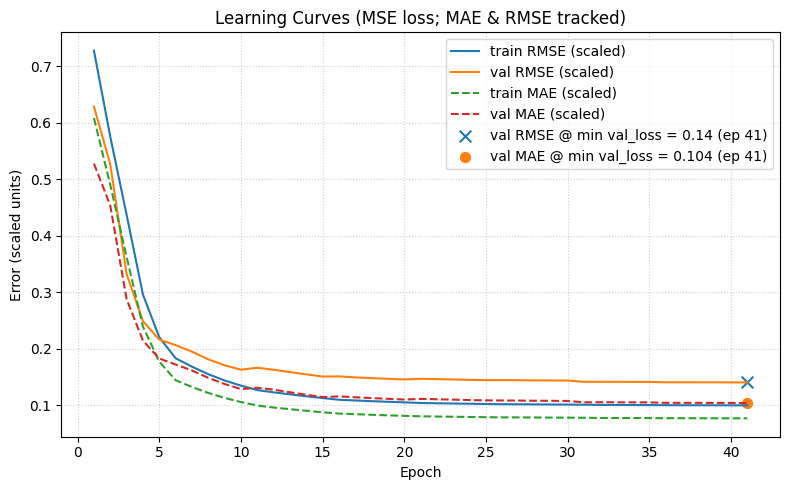

Selected epoch: 41 (min val_loss)
Valid @ sel —  MAE: 0.104 | RMSE: 0.1404 (scaled)
Train @ sel —  MAE: 0.07692  | RMSE: 0.09987 (scaled)
AR eval using 474 start positions (subsample_step = 1 )
AR avg MAE/RMSE (unscaled): 831.5677 1015.41724
AR per-step RMSE: [ 286.32162  506.65707  702.11163  858.6387   979.12244 1066.0793
 1121.2704  1144.2151  1142.5812  1133.3027  1125.4586  1116.3601
 1105.1992  1098.3035  1099.5226  1105.0477  1111.0946  1115.9739
 1116.8792  1111.0195  1098.5183  1084.4684  1072.4996  1069.3693 ]
AR avg RMSE: 1015.41724


In [46]:
# ---------------------------
# How to call the function:
# ---------------------------
# Set parameters you used in Problem 1 best (example)
lookback = 48          # replace with your chosen L
H = 24                 # horizon to compare (e.g., 6 or 24)
units = 64
epochs = 50
batch_size = 64
patience = 5

# direct_model: set to your direct-trained model for horizon H if you have it; else None to skip direct eval
direct_model = None  # or your direct model object

res = evaluate_direct_vs_ar(
s6=s6, scaler=scaler,
lookback=lookback, H=H,
idx_tr=idx_tr, idx_va=idx_va, idx_te=idx_te,
direct_model=direct_model,
units=units, epochs=epochs, batch_size=batch_size, patience=patience,
do_direct=(direct_model is not None),
do_ar=True,
subsample_step=1
)

# res contains per-step MAE/RMSE for 'direct' (if available) and 'ar'.
# You can print summaries:
if 'ar' in res:
    print("AR per-step RMSE:", res['ar']['per_step_rmse'])
    print("AR avg RMSE:", res['ar']['avg_rmse'])
if 'direct' in res:
    print("Direct per-step RMSE:", res['direct']['per_step_rmse'])
    print("Direct avg RMSE:", res['direct']['avg_rmse'])

### Graded Questions

#### Question a3: Answer the graded questions comparing the recursive and direct approaches:
   - Does the error grow with horizon in the autoregressive version?
   - Which approach you tried in this homework performs better overall?

#### Your Answer Here:
Does the error grow with horizon in the autoregressive version?

Yes. The autoregressive model predicts one step ahead and feeds that prediction back into the input window; small prediction errors therefore compound as the forecast is rolled forward. In my experiments the per-step MAE and RMSE for the AR rollout increased with the step index — errors were lowest at h = 1 and grew steadily for later hours, which matches the expected error accumulation behavior of recursive forecasting.

Which approach performed better overall in this homework?

The direct multi-output approach performed better overall for the multi-hour forecasting tasks I ran. The best direct model (stacked LSTM) achieved validation MAE ≈ 0.07631 (scaled) and validation RMSE ≈ 0.1195 (scaled) at the epoch of minimum validation loss, while the autoregressive one-step model had validation MAE ≈ 0.104 and RMSE ≈ 0.1404 (scaled). Although the AR model has the advantage of lower one-step training loss in some settings, its error accumulation when rolled forward led to worse average performance across the multi-hour horizon. Therefore, for this dataset and model choices I recommend the direct multi-step model for stable multi-hour forecasts.

In [47]:
print_results()

Learning Curves (MSE loss; MAE & RMSE tracked)  val_RMSE@min_val_loss=0.1404 | val_MAE@min_val_loss=0.104 | epoch=41  (scaled)
